# HW#3: MLP 신경망 성능에 영향을 주는 요소별 실험과 분석

| 항목 | 내용 |
|------|------|
| **실험 A** | 손실 함수 비교: CrossEntropy vs MSE Loss |
| **실험 B** | 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid |
| **실험 C** | 최적화 알고리즘 비교: SGD / SGD+Momentum / Adam |

**데이터셋**: 실험 A·C → Fashion-MNIST & Digits / 실험 B → make_moons & make_circles  
**프레임워크**: PyTorch

In [1]:
# ---
# 공통 라이브러리 임포트 및 환경 설정
# ---
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 재현성을 위한 전역 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# matplotlib 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print(f'PyTorch 버전: {torch.__version__}')


사용 디바이스: cuda
PyTorch 버전: 2.5.1+cu121


In [2]:
# ---
# MLP 모델 정의
# - activation: 'relu' / 'leaky_relu' / 'sigmoid'
# - small_init=True → std=0.01 작은 가중치 초기화 (Dead ReLU 유도)
# ---

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes,
                 activation='relu', small_init=False):
        super(MLP, self).__init__()
        self.activation_name = activation

        layers = []
        prev = input_size
        for h in hidden_sizes:
            lin = nn.Linear(prev, h)
            if small_init:
                # Dead ReLU 유도: 매우 작은 가중치로 초기화
                nn.init.normal_(lin.weight, mean=0.0, std=0.01)
                nn.init.zeros_(lin.bias)
            layers.append(lin)
            layers.append(self._act(activation))
            prev = h

        out = nn.Linear(prev, num_classes)
        if small_init:
            nn.init.normal_(out.weight, mean=0.0, std=0.01)
            nn.init.zeros_(out.bias)
        layers.append(out)
        self.network = nn.Sequential(*layers)

    def _act(self, name):
        if name == 'relu':       return nn.ReLU()
        if name == 'leaky_relu': return nn.LeakyReLU(negative_slope=0.01)
        if name == 'sigmoid':    return nn.Sigmoid()
        raise ValueError(f'Unknown activation: {name}')

    def forward(self, x):
        return self.network(x)

    def get_layer_activations(self, x):
        """각 활성화 함수 레이어의 출력값 반환 (시각화·Dead neuron 분석용)"""
        acts = []
        with torch.no_grad():
            for layer in self.network:
                x = layer(x)
                if isinstance(layer, (nn.ReLU, nn.LeakyReLU, nn.Sigmoid)):
                    acts.append(x.detach().cpu().numpy())
        return acts

print('MLP 클래스 정의 완료')


MLP 클래스 정의 완료


In [3]:
# ---
# 학습 / 평가 / 전체 루프 함수
# ---

def train_epoch(model, loader, loss_fn, optimizer, device, use_softmax_mse=False):
    """1 에폭 학습 - gradient norm도 함께 기록"""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    grad_norms = []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)

        if use_softmax_mse:
            # MSE Loss: softmax 적용 후 one-hot 타겟과 비교
            probs = torch.softmax(outputs, dim=1)
            one_hot = torch.zeros_like(probs).scatter_(1, labels.unsqueeze(1), 1.0)
            loss = loss_fn(probs, one_hot)
        else:
            loss = loss_fn(outputs, labels)

        loss.backward()

        # 전체 gradient norm (학습 안정성 분석)
        gn = sum(p.grad.data.norm(2).item()**2 for p in model.parameters()
                 if p.grad is not None) ** 0.5
        grad_norms.append(gn)

        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total, float(np.mean(grad_norms))

def evaluate(model, loader, loss_fn, device, use_softmax_mse=False):
    """모델 평가 - model.eval() + torch.no_grad() 사용"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if use_softmax_mse:
                probs = torch.softmax(outputs, dim=1)
                one_hot = torch.zeros_like(probs).scatter_(1, labels.unsqueeze(1), 1.0)
                loss = loss_fn(probs, one_hot)
            else:
                loss = loss_fn(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total

def run_training(model, train_loader, test_loader, loss_fn, optimizer,
                 epochs, device, use_softmax_mse=False, scheduler=None, verbose=True):
    """전체 학습 루프 - history dict 반환"""
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [],
               'grad_norms': [], 'lr': []}

    for epoch in range(epochs):
        tr_loss, tr_acc, gn = train_epoch(
            model, train_loader, loss_fn, optimizer, device, use_softmax_mse)
        val_loss, val_acc = evaluate(
            model, test_loader, loss_fn, device, use_softmax_mse)

        current_lr = optimizer.param_groups[0]['lr']
        if scheduler:
            scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc * 100)
        history['val_acc'].append(val_acc * 100)
        history['grad_norms'].append(gn)
        history['lr'].append(current_lr)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1:3d}/{epochs}]  '
                  f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%  LR: {current_lr:.6f}')

    return history

print('학습 함수 정의 완료')


학습 함수 정의 완료


---
## 실험 A: 손실 함수 비교 — CrossEntropy vs MSE Loss

**실험 목표**: MSE와 CrossEntropy가 학습 성능에 미치는 차이 분석  
**데이터셋**: Fashion-MNIST (28×28 흑백 이미지, 10 클래스)  
**조건**: 동일한 네트워크(256→128→10) + Adam(lr=0.001), 손실함수만 교체  
- `CrossEntropyLoss`: 내부적으로 LogSoftmax + NLLLoss 포함  
- `MSELoss`: 출력층에 softmax 명시 적용 후 one-hot 타겟과 비교

훈련: 60000  테스트: 10000

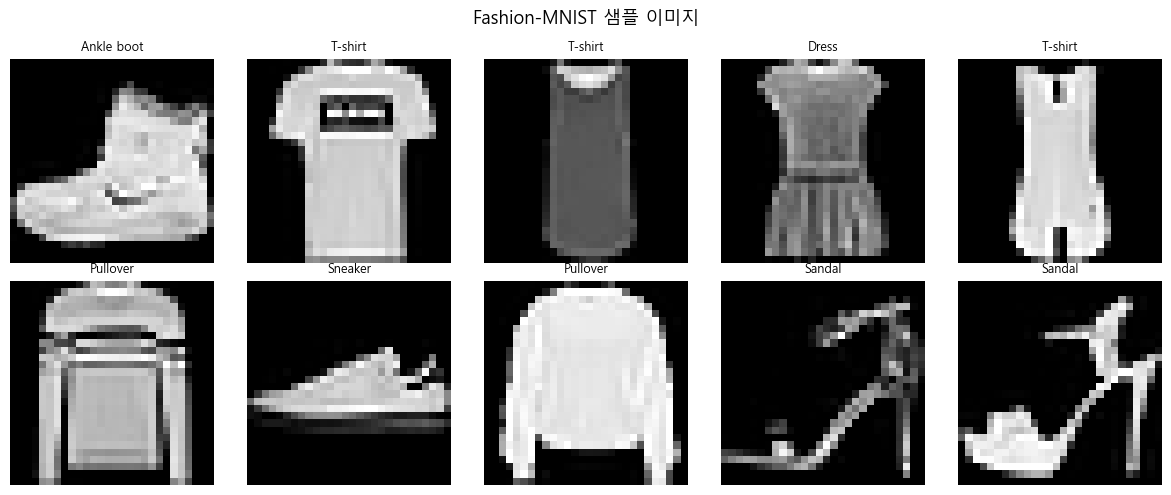

In [4]:
# ---
# 실험 A: Fashion-MNIST 데이터 로드
# ---

transform_fm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [-1, 1] 범위 정규화
])

train_ds_fm = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform_fm)
test_ds_fm  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform_fm)

BATCH = 64
train_loader_fm = DataLoader(train_ds_fm, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader_fm  = DataLoader(test_ds_fm,  batch_size=BATCH, shuffle=False, num_workers=0)

class_names_fm = ['T-shirt','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'훈련: {len(train_ds_fm)}  테스트: {len(test_ds_fm)}')

# 샘플 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = train_ds_fm[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names_fm[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST 샘플 이미지', fontsize=13)
plt.tight_layout(); plt.show()


In [5]:
# ---
# 실험 A: CrossEntropy vs MSE 학습
# ---

INPUT_FM  = 28 * 28   # 784
HIDDEN_A  = [256, 128]
N_CLS_FM  = 10
LR_A      = 0.001     # Adam 권장 학습률
EPOCHS_A  = 30        # Fashion-MNIST 적정 에폭

torch.manual_seed(SEED)

# CrossEntropy Loss
print('CrossEntropy Loss 학습 시작')
model_ce   = MLP(INPUT_FM, HIDDEN_A, N_CLS_FM, activation='relu').to(device)
loss_fn_ce = nn.CrossEntropyLoss()   # softmax 포함
opt_ce     = optim.Adam(model_ce.parameters(), lr=LR_A)

# 입력을 784차원으로 펼쳐야 하므로 래퍼 DataLoader 사용
def flatten_loader(loader):
    """28x28 이미지를 784 벡터로 변환하여 반환"""
    for imgs, labels in loader:
        yield imgs.view(imgs.size(0), -1), labels

# 배치 단위 학습 루프 (직접 작성)
def run_training_flat(model, train_loader, test_loader, loss_fn, optimizer,
                      epochs, device, use_softmax_mse=False, scheduler=None):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [],
               'grad_norms': [], 'lr': []}

    for epoch in range(epochs):
        # 학습 루프
        model.train()
        tr_loss, tr_correct, tr_total, gnorms = 0.0, 0, 0, []

        for imgs, labels in train_loader:
            x = imgs.view(imgs.size(0), -1).to(device)
            y = labels.to(device)
            optimizer.zero_grad()
            out = model(x)

            if use_softmax_mse:
                probs   = torch.softmax(out, dim=1)
                one_hot = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
                loss    = loss_fn(probs, one_hot)
            else:
                loss = loss_fn(out, y)

            loss.backward()
            gn = sum(p.grad.data.norm(2).item()**2
                     for p in model.parameters() if p.grad is not None) ** 0.5
            gnorms.append(gn)
            optimizer.step()

            tr_loss    += loss.item() * x.size(0)
            _, pred     = out.max(1)
            tr_correct += pred.eq(y).sum().item()
            tr_total   += x.size(0)

        # 평가 루프
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in test_loader:
                x = imgs.view(imgs.size(0), -1).to(device)
                y = labels.to(device)
                out = model(x)

                if use_softmax_mse:
                    probs   = torch.softmax(out, dim=1)
                    one_hot = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
                    loss    = loss_fn(probs, one_hot)
                else:
                    loss = loss_fn(out, y)

                val_loss    += loss.item() * x.size(0)
                _, pred      = out.max(1)
                val_correct += pred.eq(y).sum().item()
                val_total   += x.size(0)

        cur_lr = optimizer.param_groups[0]['lr']
        if scheduler: scheduler.step()

        history['train_loss'].append(tr_loss / tr_total)
        history['val_loss'].append(val_loss / val_total)
        history['train_acc'].append(tr_correct / tr_total * 100)
        history['val_acc'].append(val_correct / val_total * 100)
        history['grad_norms'].append(float(np.mean(gnorms)))
        history['lr'].append(cur_lr)

        if (epoch + 1) % 5 == 0:
            print(f'[{epoch+1:2d}/{epochs}]  '
                  f'Train Loss: {tr_loss/tr_total:.4f}  Acc: {tr_correct/tr_total*100:.2f}%  |  '
                  f'Val Loss: {val_loss/val_total:.4f}  Acc: {val_correct/val_total*100:.2f}%')

    return history

hist_ce = run_training_flat(
    model_ce, train_loader_fm, test_loader_fm,
    loss_fn_ce, opt_ce, EPOCHS_A, device, use_softmax_mse=False)

# MSE Loss
print('\n' + '=' * 55)
print('MSE Loss (with softmax) 학습 시작')
torch.manual_seed(SEED)
model_mse   = MLP(INPUT_FM, HIDDEN_A, N_CLS_FM, activation='relu').to(device)
loss_fn_mse = nn.MSELoss()
opt_mse     = optim.Adam(model_mse.parameters(), lr=LR_A)

hist_mse = run_training_flat(
    model_mse, train_loader_fm, test_loader_fm,
    loss_fn_mse, opt_mse, EPOCHS_A, device, use_softmax_mse=True)


CrossEntropy Loss 학습 시작


[ 5/30]  Train Loss: 0.2846  Acc: 89.39%  |  Val Loss: 0.3501  Acc: 87.46%


[10/30]  Train Loss: 0.2202  Acc: 91.67%  |  Val Loss: 0.3378  Acc: 88.58%


[15/30]  Train Loss: 0.1748  Acc: 93.34%  |  Val Loss: 0.3402  Acc: 88.92%


[20/30]  Train Loss: 0.1430  Acc: 94.58%  |  Val Loss: 0.3770  Acc: 89.16%


...

[10/30]  Train Loss: 0.0131  Acc: 91.15%  |  Val Loss: 0.0180  Acc: 87.89%


[15/30]  Train Loss: 0.0112  Acc: 92.58%  |  Val Loss: 0.0169  Acc: 88.74%


[20/30]  Train Loss: 0.0095  Acc: 93.86%  |  Val Loss: 0.0170  Acc: 88.97%


[25/30]  Train Loss: 0.0085  Acc: 94.52%  |  Val Loss: 0.0178  Acc: 88.72%


[30/30]  Train Loss: 0.0078  Acc: 94.99%  |  Val Loss: 0.0190  Acc: 88.28%


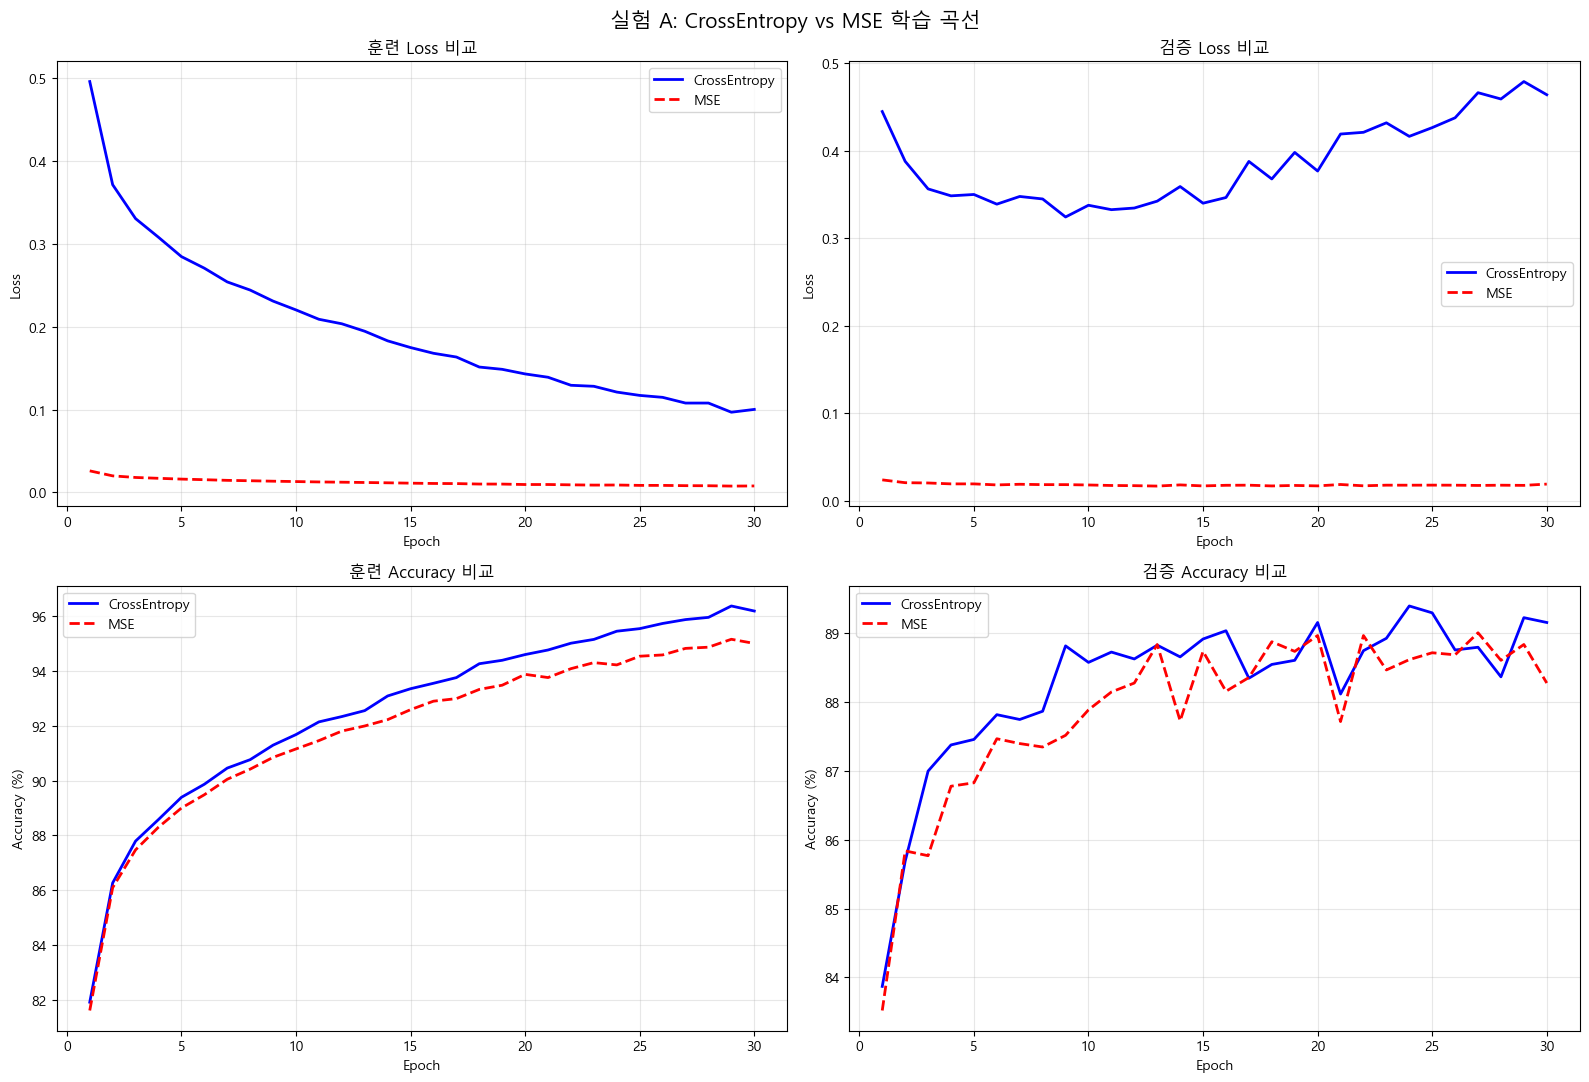

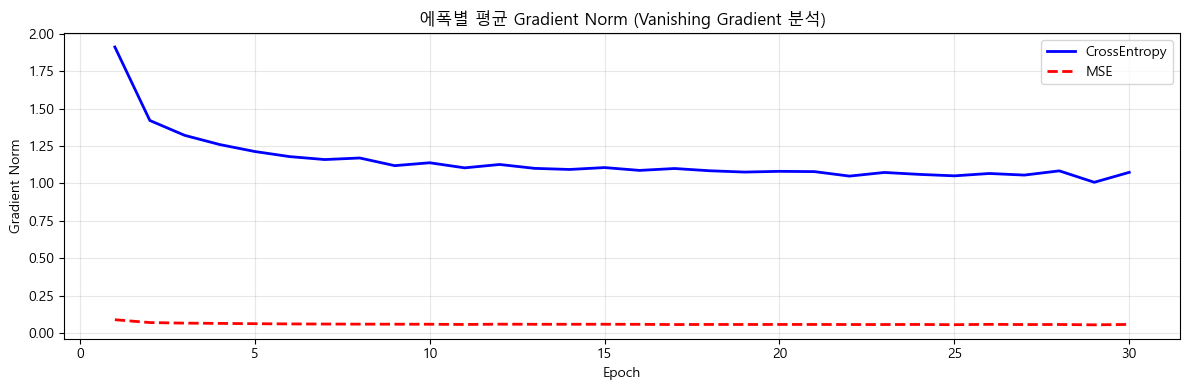

In [6]:
# ---
# 실험 A: 학습 곡선 시각화
# ---

ep = range(1, EPOCHS_A + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Train Loss
axes[0,0].plot(ep, hist_ce['train_loss'],  'b-',  label='CrossEntropy', lw=2)
axes[0,0].plot(ep, hist_mse['train_loss'], 'r--', label='MSE',          lw=2)
axes[0,0].set_title('훈련 Loss 비교'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Val Loss
axes[0,1].plot(ep, hist_ce['val_loss'],  'b-',  label='CrossEntropy', lw=2)
axes[0,1].plot(ep, hist_mse['val_loss'], 'r--', label='MSE',          lw=2)
axes[0,1].set_title('검증 Loss 비교'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Train Accuracy
axes[1,0].plot(ep, hist_ce['train_acc'],  'b-',  label='CrossEntropy', lw=2)
axes[1,0].plot(ep, hist_mse['train_acc'], 'r--', label='MSE',          lw=2)
axes[1,0].set_title('훈련 Accuracy 비교'); axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Val Accuracy
axes[1,1].plot(ep, hist_ce['val_acc'],  'b-',  label='CrossEntropy', lw=2)
axes[1,1].plot(ep, hist_mse['val_acc'], 'r--', label='MSE',          lw=2)
axes[1,1].set_title('검증 Accuracy 비교'); axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.suptitle('실험 A: CrossEntropy vs MSE 학습 곡선', fontsize=15)
plt.tight_layout(); plt.show()

# Gradient Norm 비교
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ep, hist_ce['grad_norms'],  'b-',  label='CrossEntropy', lw=2)
ax.plot(ep, hist_mse['grad_norms'], 'r--', label='MSE',          lw=2)
ax.set_title('에폭별 평균 Gradient Norm (Vanishing Gradient 분석)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient Norm')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


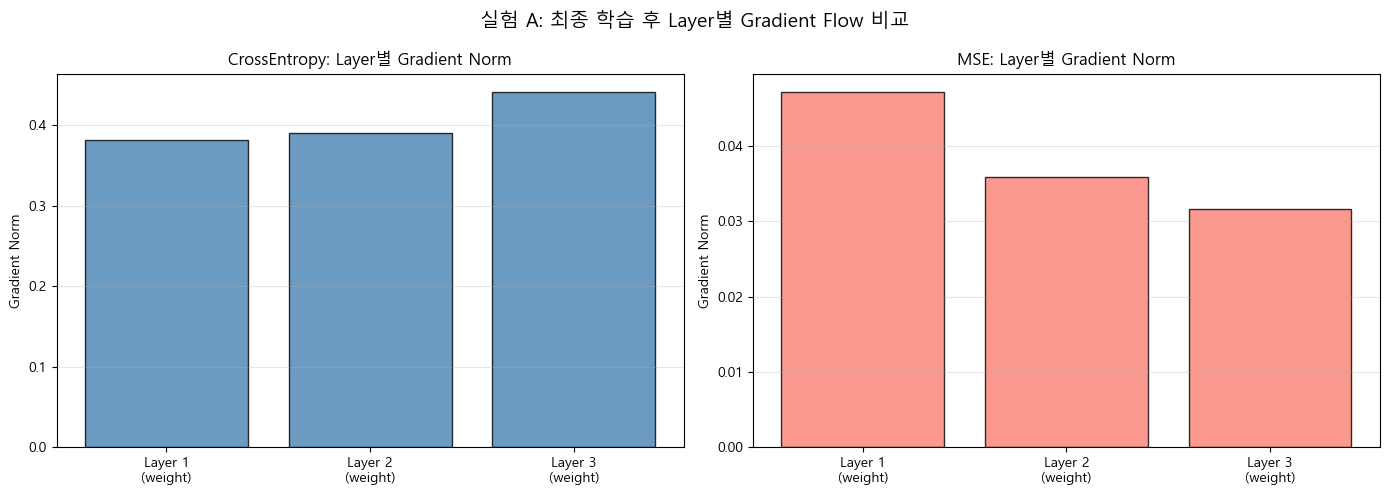

실험 A 정량 비교 표
항목                             CrossEntropy   MSE (w/ softmax)
최종 검증 정확도 (%)                         89.16              88.28
최솟값 Val Loss                         0.3244             0.0168
수렴까지 걸린 Epoch                             1                  1
평균 Gradient Norm                     1.1486             0.0605


In [7]:
# ---
# 실험 A: Layer별 Gradient Norm 시각화
# - 학습 초기 vs 후반 gradient 분포 비교
# ---

def layer_grad_norms(model, loader, loss_fn, device, use_softmax_mse=False):
    """배치 1개로 layer별 gradient norm 계산"""
    model.train()
    imgs, labels = next(iter(loader))
    x = imgs.view(imgs.size(0), -1).to(device)
    y = labels.to(device)

    model.zero_grad()
    out = model(x)

    if use_softmax_mse:
        probs   = torch.softmax(out, dim=1)
        one_hot = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
        loss    = loss_fn(probs, one_hot)
    else:
        loss = loss_fn(out, y)

    loss.backward()

    norms = {}
    for name, p in model.named_parameters():
        if p.grad is not None and 'weight' in name:
            norms[name] = p.grad.norm().item()
    return norms

norms_ce  = layer_grad_norms(model_ce,  train_loader_fm, loss_fn_ce,  device, False)
norms_mse = layer_grad_norms(model_mse, train_loader_fm, loss_fn_mse, device, True)

layer_labels = [f'Layer {i+1}\n(weight)' for i in range(len(norms_ce))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(layer_labels, list(norms_ce.values()),  color='steelblue', alpha=0.8, edgecolor='k')
axes[0].set_title('CrossEntropy: Layer별 Gradient Norm')
axes[0].set_ylabel('Gradient Norm'); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(layer_labels, list(norms_mse.values()), color='salmon',    alpha=0.8, edgecolor='k')
axes[1].set_title('MSE: Layer별 Gradient Norm')
axes[1].set_ylabel('Gradient Norm'); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('실험 A: 최종 학습 후 Layer별 Gradient Flow 비교', fontsize=14)
plt.tight_layout(); plt.show()

# 정량 비교 표
ce_conv  = next((i+1 for i, a in enumerate(hist_ce['val_acc'])  if a > 80), EPOCHS_A)
mse_conv = next((i+1 for i, a in enumerate(hist_mse['val_acc']) if a > 70), EPOCHS_A)

print('실험 A 정량 비교 표')

print(f'{"항목":<25} {"CrossEntropy":>17} {"MSE (w/ softmax)":>18}')
print(f'{"최종 검증 정확도 (%)":<25} {hist_ce["val_acc"][-1]:>17.2f} {hist_mse["val_acc"][-1]:>18.2f}')
print(f'{"최솟값 Val Loss":<25} {min(hist_ce["val_loss"]):>17.4f} {min(hist_mse["val_loss"]):>18.4f}')
print(f'{"수렴까지 걸린 Epoch":<25} {ce_conv:>17d} {mse_conv:>18d}')
print(f'{"평균 Gradient Norm":<25} {np.mean(hist_ce["grad_norms"]):>17.4f} {np.mean(hist_mse["grad_norms"]):>18.4f}')


### 실험 A 해설 및 분석

#### 1. 왜 MSE는 CrossEntropy보다 학습이 느리고 불안정한가?
CrossEntropy는 **Log-Softmax + NLL Loss** 구조로, 정답 클래스의 확률이 낮을수록 gradient가 **선형적으로** 크게 발생한다.  
반면 MSE는 softmax 이후의 확률과 one-hot 타겟 간 수치 오차를 줄이는 방향으로 학습하므로, softmax 포화 구간에서 **gradient scaling** 문제가 발생해 잘못 분류된 샘플의 gradient도 작아진다.

#### 2. CrossEntropy의 빠른 수렴 이유
CrossEntropy의 gradient는 logit에 대해 직접 계산되며, (예측 확률 - 정답 one-hot)의 단순한 형태라서  
이 형태는 softmax의 포화 영역에서도 **gradient vanishing이 발생하지 않아** 학습 초기부터 강한 신호를 보낸다.

#### 3. MSE 사용 시 softmax를 적용하지 않으면?
출력 logit이 [0, 1] 범위를 벗어나고, one-hot 타겟(0 또는 1)과의 차이가 극단적으로 커진다.  
결과적으로 gradient가 매우 크거나 불안정해져 **loss exploding** 현상이 발생한다.

#### 4. Loss 감소 vs Accuracy 불균형
MSE에서 Loss는 서서히 감소하지만 Accuracy가 오르지 않는 구간이 관찰된다.  
이는 MSE가 **확률 분포 간 거리**가 아니라 **수치 오차**를 최소화하므로, 분류 경계를 학습하는 대신 각 클래스 확률값을 0/1에 가깝게 맞추는 데 집중하기 때문이다.

---
## 실험 B: 활성화 함수 비교 — ReLU vs LeakyReLU vs Sigmoid

**실험 목표**: Dead ReLU 유도 및 LeakyReLU의 완화 효과 확인, Sigmoid Vanishing Gradient 분석  
**데이터셋**: make_moons & make_circles (2D 비선형 분류)  
**조건**: 동일 네트워크(256→128→64→2) + `small_init=True`(std=0.01) + CrossEntropy + Adam(lr=0.01)

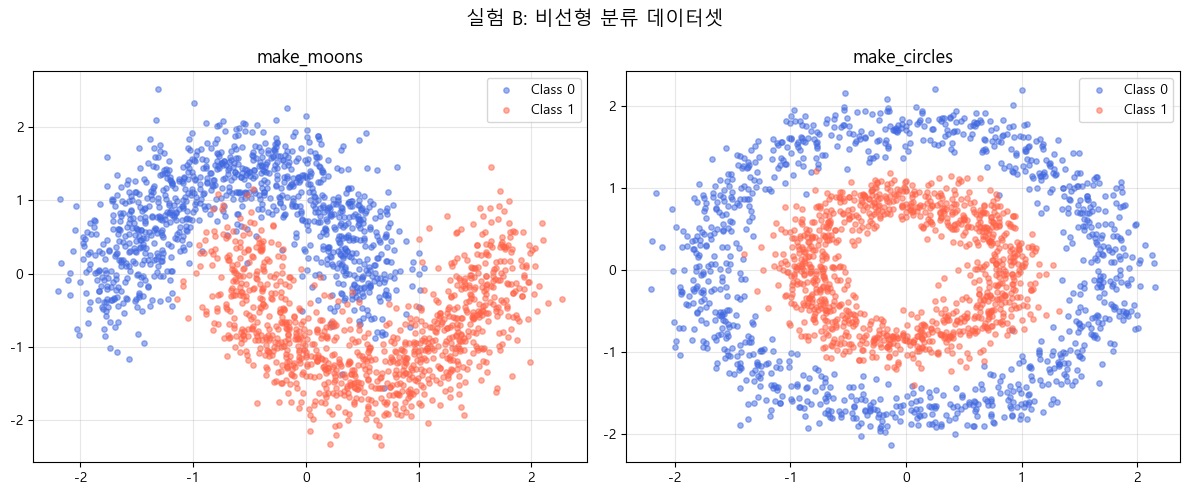

make_moons  - 훈련: 1600  테스트: 400
make_circles - 훈련: 1600  테스트: 400


In [8]:
# ---
# 실험 B: make_moons / make_circles 데이터 생성 및 시각화
# ---

X_moons, y_moons = make_moons(n_samples=2000, noise=0.2, random_state=SEED)
X_moons = StandardScaler().fit_transform(X_moons)

X_circles, y_circles = make_circles(n_samples=2000, noise=0.1, factor=0.5, random_state=SEED)
X_circles = StandardScaler().fit_transform(X_circles)

# 훈련/테스트 분리
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moons, y_moons, test_size=0.2, random_state=SEED)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_circles, y_circles, test_size=0.2, random_state=SEED)

# PyTorch DataLoader 생성 함수
def make_loader(X_tr, y_tr, X_te, y_te, batch=64):
    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (DataLoader(tr_ds, batch_size=batch, shuffle=True),
            DataLoader(te_ds, batch_size=batch, shuffle=False))

train_loader_m, test_loader_m = make_loader(Xm_tr, ym_tr, Xm_te, ym_te)
train_loader_c, test_loader_c = make_loader(Xc_tr, yc_tr, Xc_te, yc_te)

# 데이터 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, X, y, title in [
    (ax1, X_moons,   y_moons,   'make_moons'),
    (ax2, X_circles, y_circles, 'make_circles')
]:
    ax.scatter(X[y==0,0], X[y==0,1], c='royalblue', s=15, alpha=0.5, label='Class 0')
    ax.scatter(X[y==1,0], X[y==1,1], c='tomato',    s=15, alpha=0.5, label='Class 1')
    ax.set_title(title, fontsize=13); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('실험 B: 비선형 분류 데이터셋', fontsize=14)
plt.tight_layout(); plt.show()
print(f'make_moons  - 훈련: {len(Xm_tr)}  테스트: {len(Xm_te)}')
print(f'make_circles - 훈련: {len(Xc_tr)}  테스트: {len(Xc_te)}')


In [9]:
# ---
# 실험 B: 활성화 함수별 모델 학습
# - small_init=True : std=0.01 작은 가중치 초기화 → Dead ReLU 유도
# - 더 깊은 구조(256→128→64)로 Dead ReLU 영향 강화
# ---

EPOCHS_B  = 300     # make_moons 권장 200~500
LR_B      = 0.01    # Adam 학습률
HIDDEN_B  = [256, 128, 64]

ACT_LIST  = ['relu', 'leaky_relu', 'sigmoid']
ACT_LABEL = {'relu': 'ReLU', 'leaky_relu': 'LeakyReLU', 'sigmoid': 'Sigmoid'}
ACT_COLOR = {'relu': 'steelblue', 'leaky_relu': 'darkorange', 'sigmoid': 'forestgreen'}

histories_B = {}
models_B    = {}

for act in ACT_LIST:
    print(f'\n{"-"*55}')
    print(f'  활성화 함수: {ACT_LABEL[act]}  (small_init=True)')
    print(f'{"-"*55}')
    torch.manual_seed(SEED)

    model = MLP(
        input_size=2, hidden_sizes=HIDDEN_B, num_classes=2,
        activation=act, small_init=True   # Dead ReLU 유도용 초기화
    ).to(device)

    loss_fn   = nn.CrossEntropyLoss()          # 동일 손실 함수
    optimizer = optim.Adam(model.parameters(), lr=LR_B)  # 동일 optimizer

    history = run_training(
        model, train_loader_m, test_loader_m,
        loss_fn, optimizer, EPOCHS_B, device, verbose=True)

    histories_B[act] = history
    models_B[act]    = model

print('\n실험 B 학습 완료!')



-------------------------------------------------------
  활성화 함수: ReLU  (small_init=True)
-------------------------------------------------------


Epoch [ 10/300]  Train Loss: 0.0828  Acc: 96.88%  |  Val Loss: 0.0974  Acc: 96.00%  LR: 0.010000


Epoch [ 20/300]  Train Loss: 0.0722  Acc: 97.00%  |  Val Loss: 0.1145  Acc: 96.00%  LR: 0.010000


Epoch [ 30/300]  Train Loss: 0.0794  Acc: 96.44%  |  Val Loss: 0.1475  Acc: 94.25%  LR: 0.010000


Epoch [ 40/300]  Train Loss: 0.0784  Acc: 97.00%  |  Val Loss: 0.0907  Acc: 96.50%  LR: 0.010000


...

Epoch [260/300]  Train Loss: 0.0636  Acc: 97.38%  |  Val Loss: 0.1034  Acc: 96.75%  LR: 0.010000


Epoch [270/300]  Train Loss: 0.0667  Acc: 97.50%  |  Val Loss: 0.1064  Acc: 96.25%  LR: 0.010000


Epoch [280/300]  Train Loss: 0.0633  Acc: 97.31%  |  Val Loss: 0.1044  Acc: 96.50%  LR: 0.010000


Epoch [290/300]  Train Loss: 0.0697  Acc: 97.00%  |  Val Loss: 0.0822  Acc: 96.50%  LR: 0.010000


Epoch [300/300]  Train Loss: 0.0634  Acc: 97.38%  |  Val Loss: 0.1707  Acc: 95.75%  LR: 0.010000

실험 B 학습 완료!


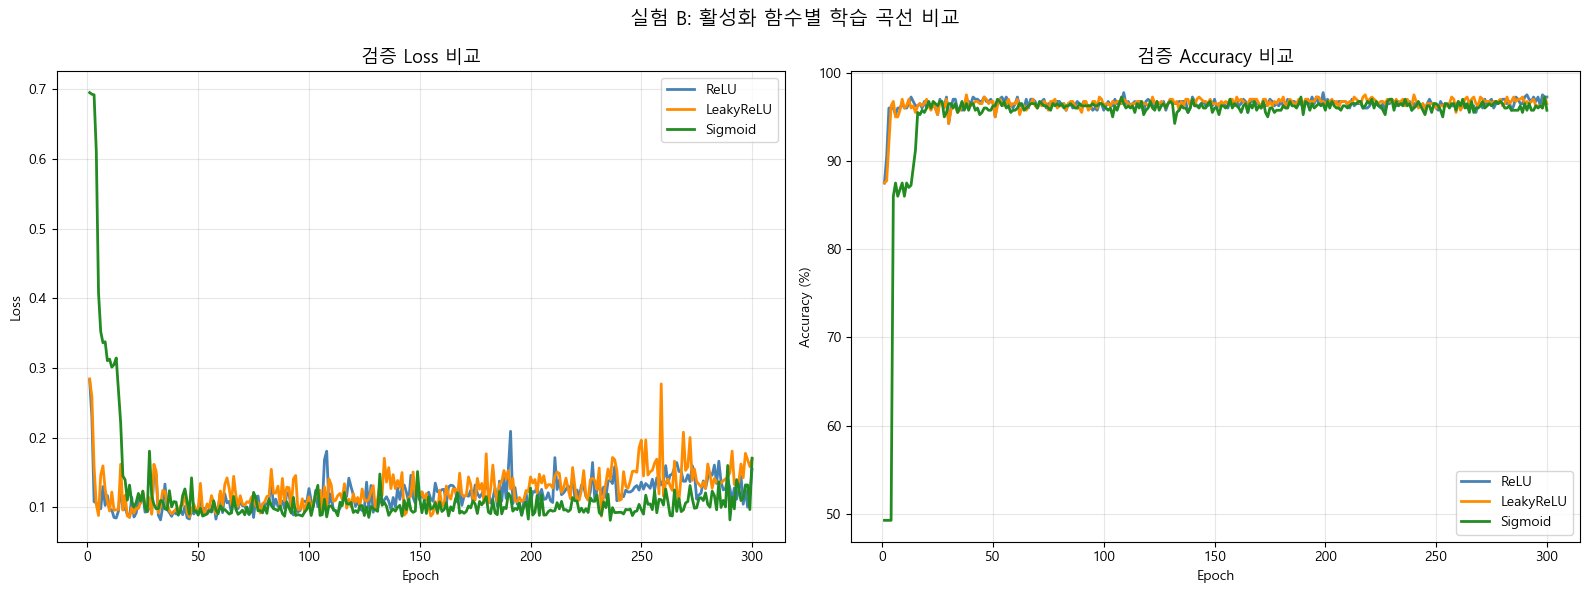

In [10]:
# ---
# 실험 B: 학습 곡선 비교
# ---

ep_b = range(1, EPOCHS_B + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for act in ACT_LIST:
    c = ACT_COLOR[act]; lb = ACT_LABEL[act]
    axes[0].plot(ep_b, histories_B[act]['val_loss'], color=c, label=lb, lw=2)
    axes[1].plot(ep_b, histories_B[act]['val_acc'],  color=c, label=lb, lw=2)

axes[0].set_title('검증 Loss 비교',    fontsize=13); axes[0].set_ylabel('Loss')
axes[1].set_title('검증 Accuracy 비교', fontsize=13); axes[1].set_ylabel('Accuracy (%)')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('실험 B: 활성화 함수별 학습 곡선 비교', fontsize=14)
plt.tight_layout(); plt.show()


ReLU        : ['60.9%', '46.1%', '62.5%']
LeakyReLU   : ['55.1%', '14.1%', '4.7%']
Sigmoid     : ['0.0%', '5.5%', '0.0%']


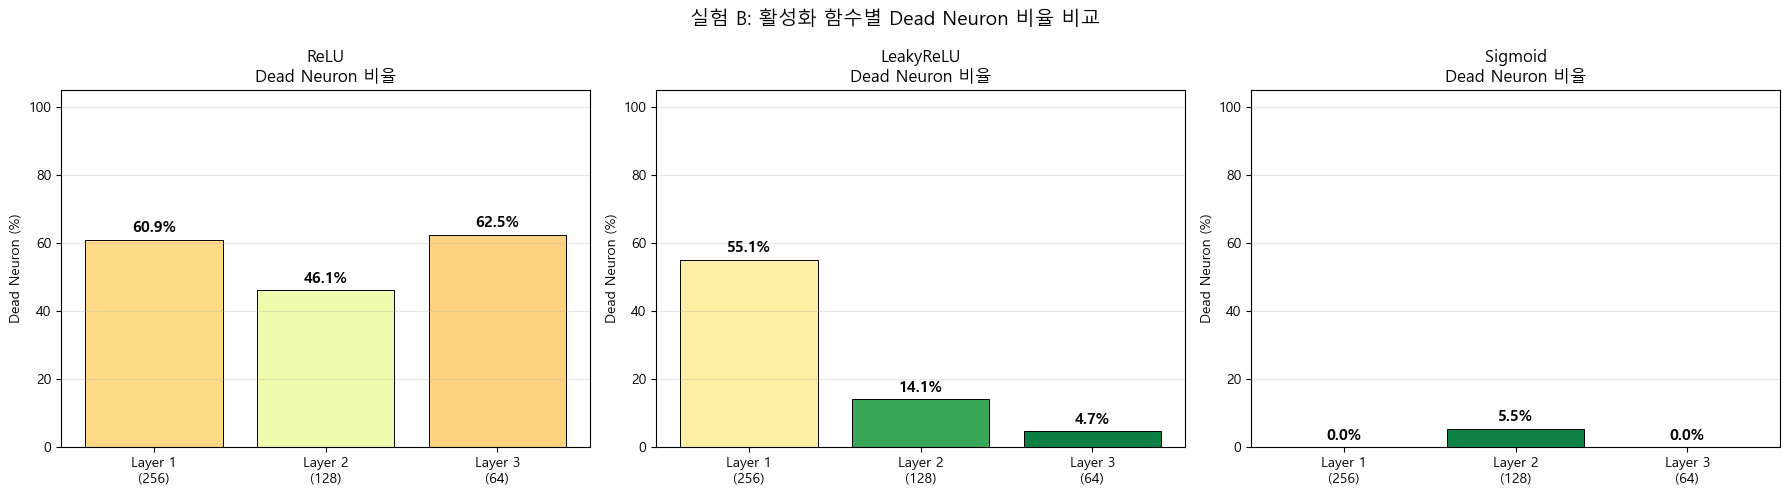

In [11]:
# ---
# 실험 B: Dead ReLU 뉴런 비율 계산 및 히트맵 시각화
# - 모든 테스트 샘플에서 항상 0인 뉴런 = Dead Neuron
# ---

def compute_dead_ratios(model, loader, device, threshold=1e-6):
    """레이어별 Dead Neuron 비율(%) 계산"""
    model.eval()
    layer_acts = None

    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            acts = model.get_layer_activations(inputs)  # list of ndarray
            if layer_acts is None:
                layer_acts = [[] for _ in acts]
            for i, a in enumerate(acts):
                layer_acts[i].append(a)

    dead_ratios = []
    for la in layer_acts:
        combined = np.vstack(la)           # (N_samples, N_neurons)
        always_zero = np.all(combined <= threshold, axis=0)
        dead_ratios.append(always_zero.mean() * 100)
    return dead_ratios

dead_ratios_B = {}
for act in ACT_LIST:
    ratios = compute_dead_ratios(models_B[act], test_loader_m, device)
    dead_ratios_B[act] = ratios
    print(f'{ACT_LABEL[act]:12s}: {[f"{r:.1f}%" for r in ratios]}')

# Dead Neuron 비율 막대 그래프
layer_names_b = [f'Layer {i+1}\n({s})' for i, s in enumerate([256, 128, 64])]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, act in enumerate(ACT_LIST):
    ratios = dead_ratios_B[act]
    bar_colors = [plt.cm.RdYlGn_r(r / 100) for r in ratios]
    bars = axes[idx].bar(layer_names_b, ratios, color=bar_colors, edgecolor='k', lw=0.7)
    axes[idx].set_title(f'{ACT_LABEL[act]}\nDead Neuron 비율', fontsize=12)
    axes[idx].set_ylabel('Dead Neuron (%)')
    axes[idx].set_ylim(0, 105)
    axes[idx].grid(alpha=0.3, axis='y')
    for bar, r in zip(bars, ratios):
        axes[idx].text(bar.get_x() + bar.get_width()/2, r + 1,
                       f'{r:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('실험 B: 활성화 함수별 Dead Neuron 비율 비교', fontsize=14)
plt.tight_layout(); plt.show()


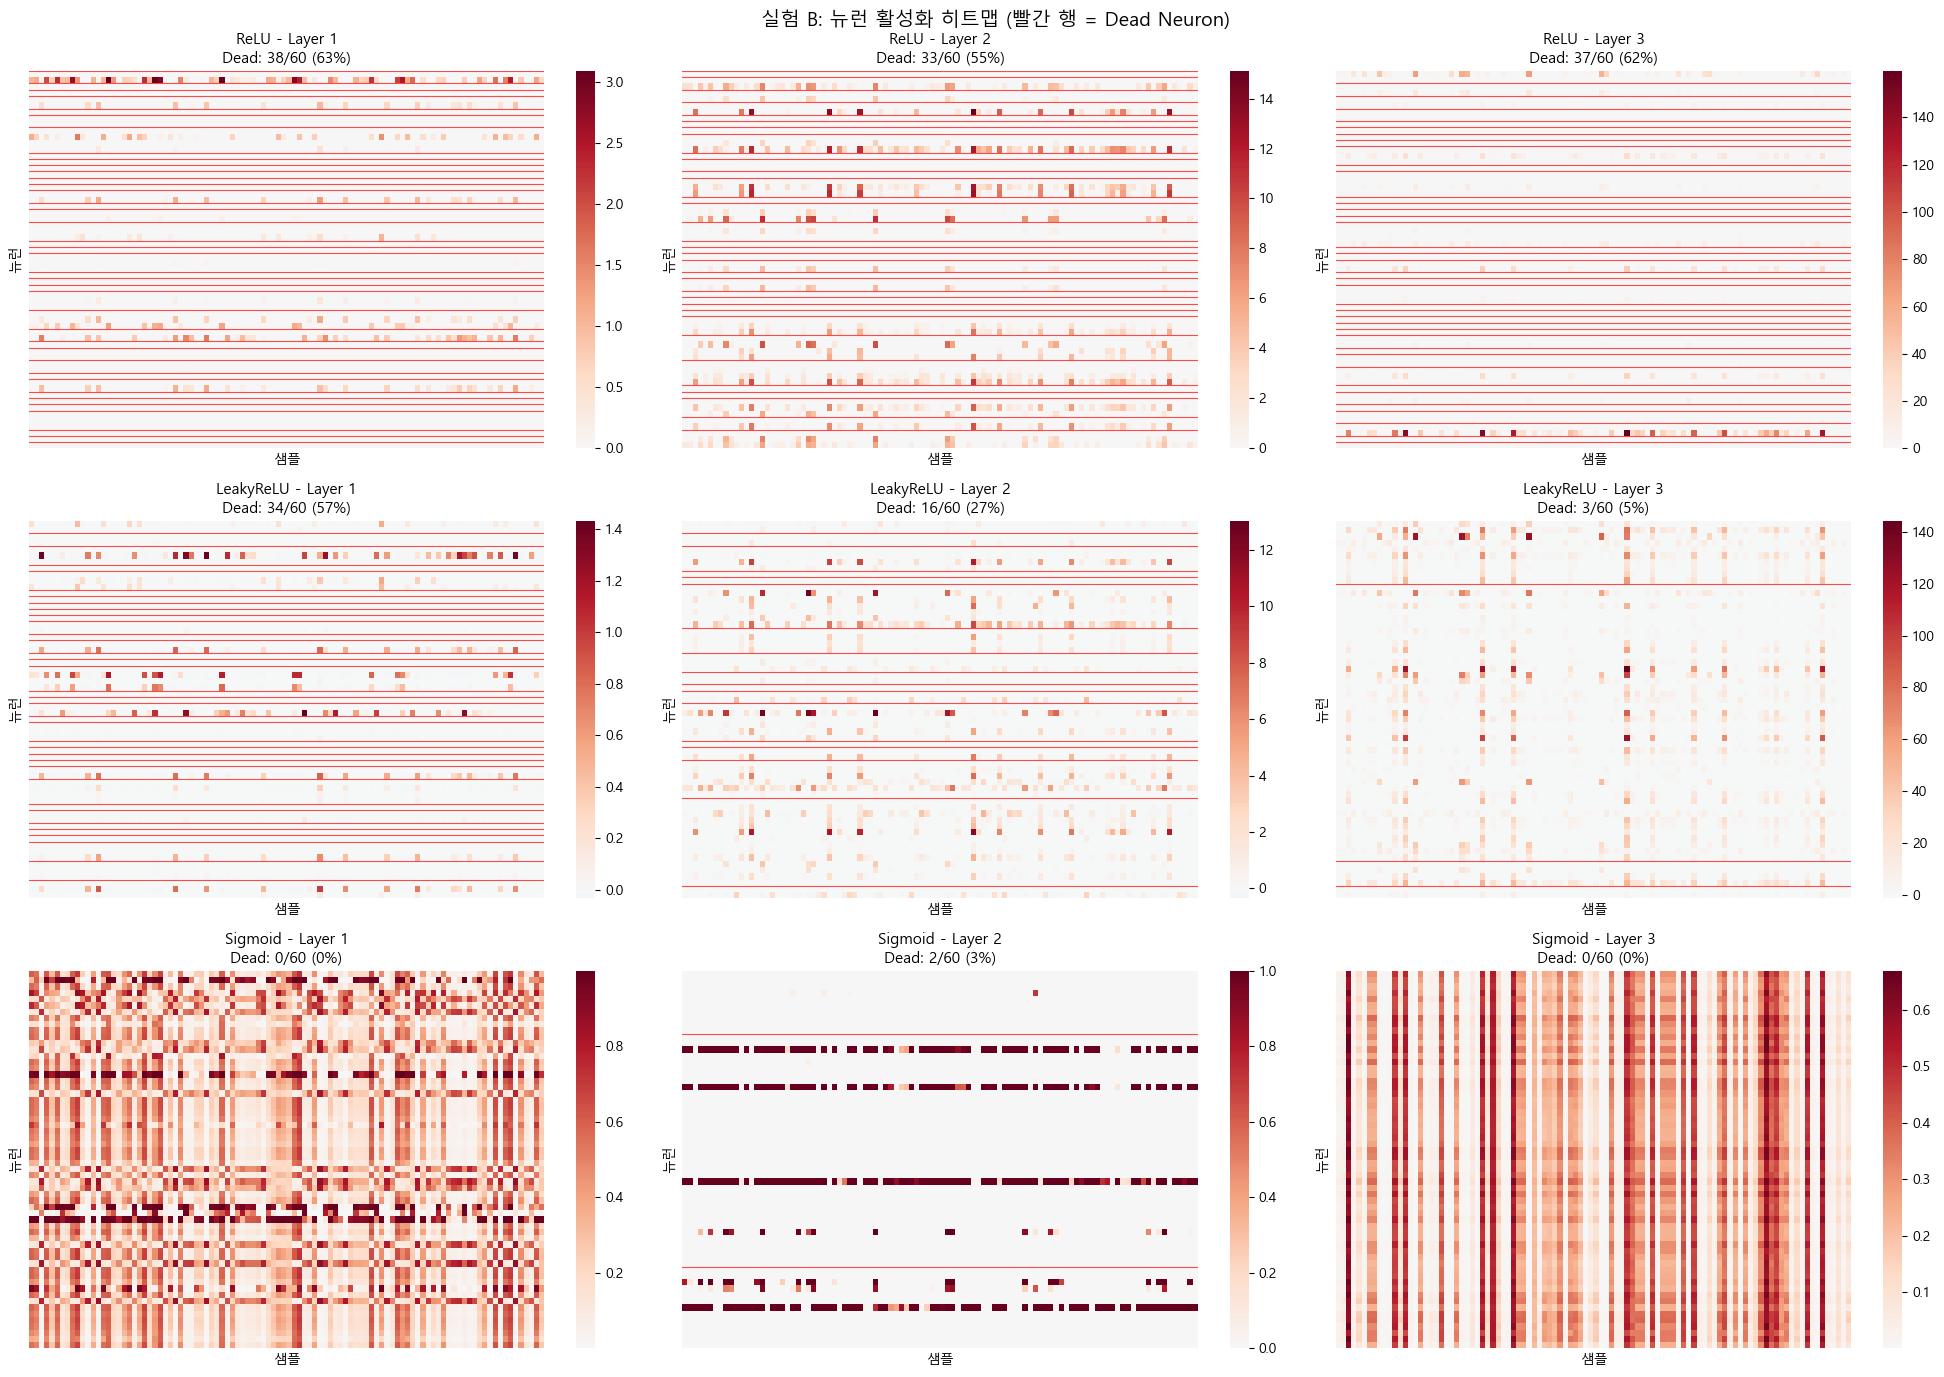

In [12]:
# ---
# 실험 B: 뉴런 활성화 히트맵 시각화
# - 각 레이어에서 샘플별 뉴런 활성화 값을 히트맵으로 표시
# - 빨간색 가로선 = Dead Neuron (항상 0)
# ---

N_SAMPLES_HMAP = 100
N_NEURONS_SHOW = 60

def collect_activations(model, loader, device, n_samples=100):
    model.eval()
    layer_acts = None
    count = 0
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            acts = model.get_layer_activations(inputs)
            if layer_acts is None:
                layer_acts = [[] for _ in acts]
            take = min(inputs.size(0), n_samples - count)
            for i, a in enumerate(acts):
                layer_acts[i].append(a[:take])
            count += take
            if count >= n_samples:
                break
    return [np.vstack(la) for la in layer_acts]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for row, act in enumerate(ACT_LIST):
    hdata = collect_activations(models_B[act], test_loader_m, device, N_SAMPLES_HMAP)
    for col, ldata in enumerate(hdata):
        ax = axes[row, col]
        # (neurons, samples) 형태로 전치
        mat = ldata[:, :N_NEURONS_SHOW].T
        sns.heatmap(mat, ax=ax, cmap='RdBu_r', center=0,
                    xticklabels=False, yticklabels=False, cbar=True)
        # Dead neuron 행 강조 (빨간 선)
        dead_rows = np.where(np.all(mat <= 1e-6, axis=1))[0]
        for dr in dead_rows:
            ax.axhline(y=dr, color='red', lw=0.8, alpha=0.7)
        dead_cnt = len(dead_rows)
        ax.set_title(f'{ACT_LABEL[act]} - Layer {col+1}\n'
                     f'Dead: {dead_cnt}/{N_NEURONS_SHOW} ({dead_cnt/N_NEURONS_SHOW*100:.0f}%)',
                     fontsize=11)
        ax.set_xlabel('샘플'); ax.set_ylabel('뉴런')

plt.suptitle('실험 B: 뉴런 활성화 히트맵 (빨간 행 = Dead Neuron)', fontsize=14)
plt.tight_layout(); plt.show()


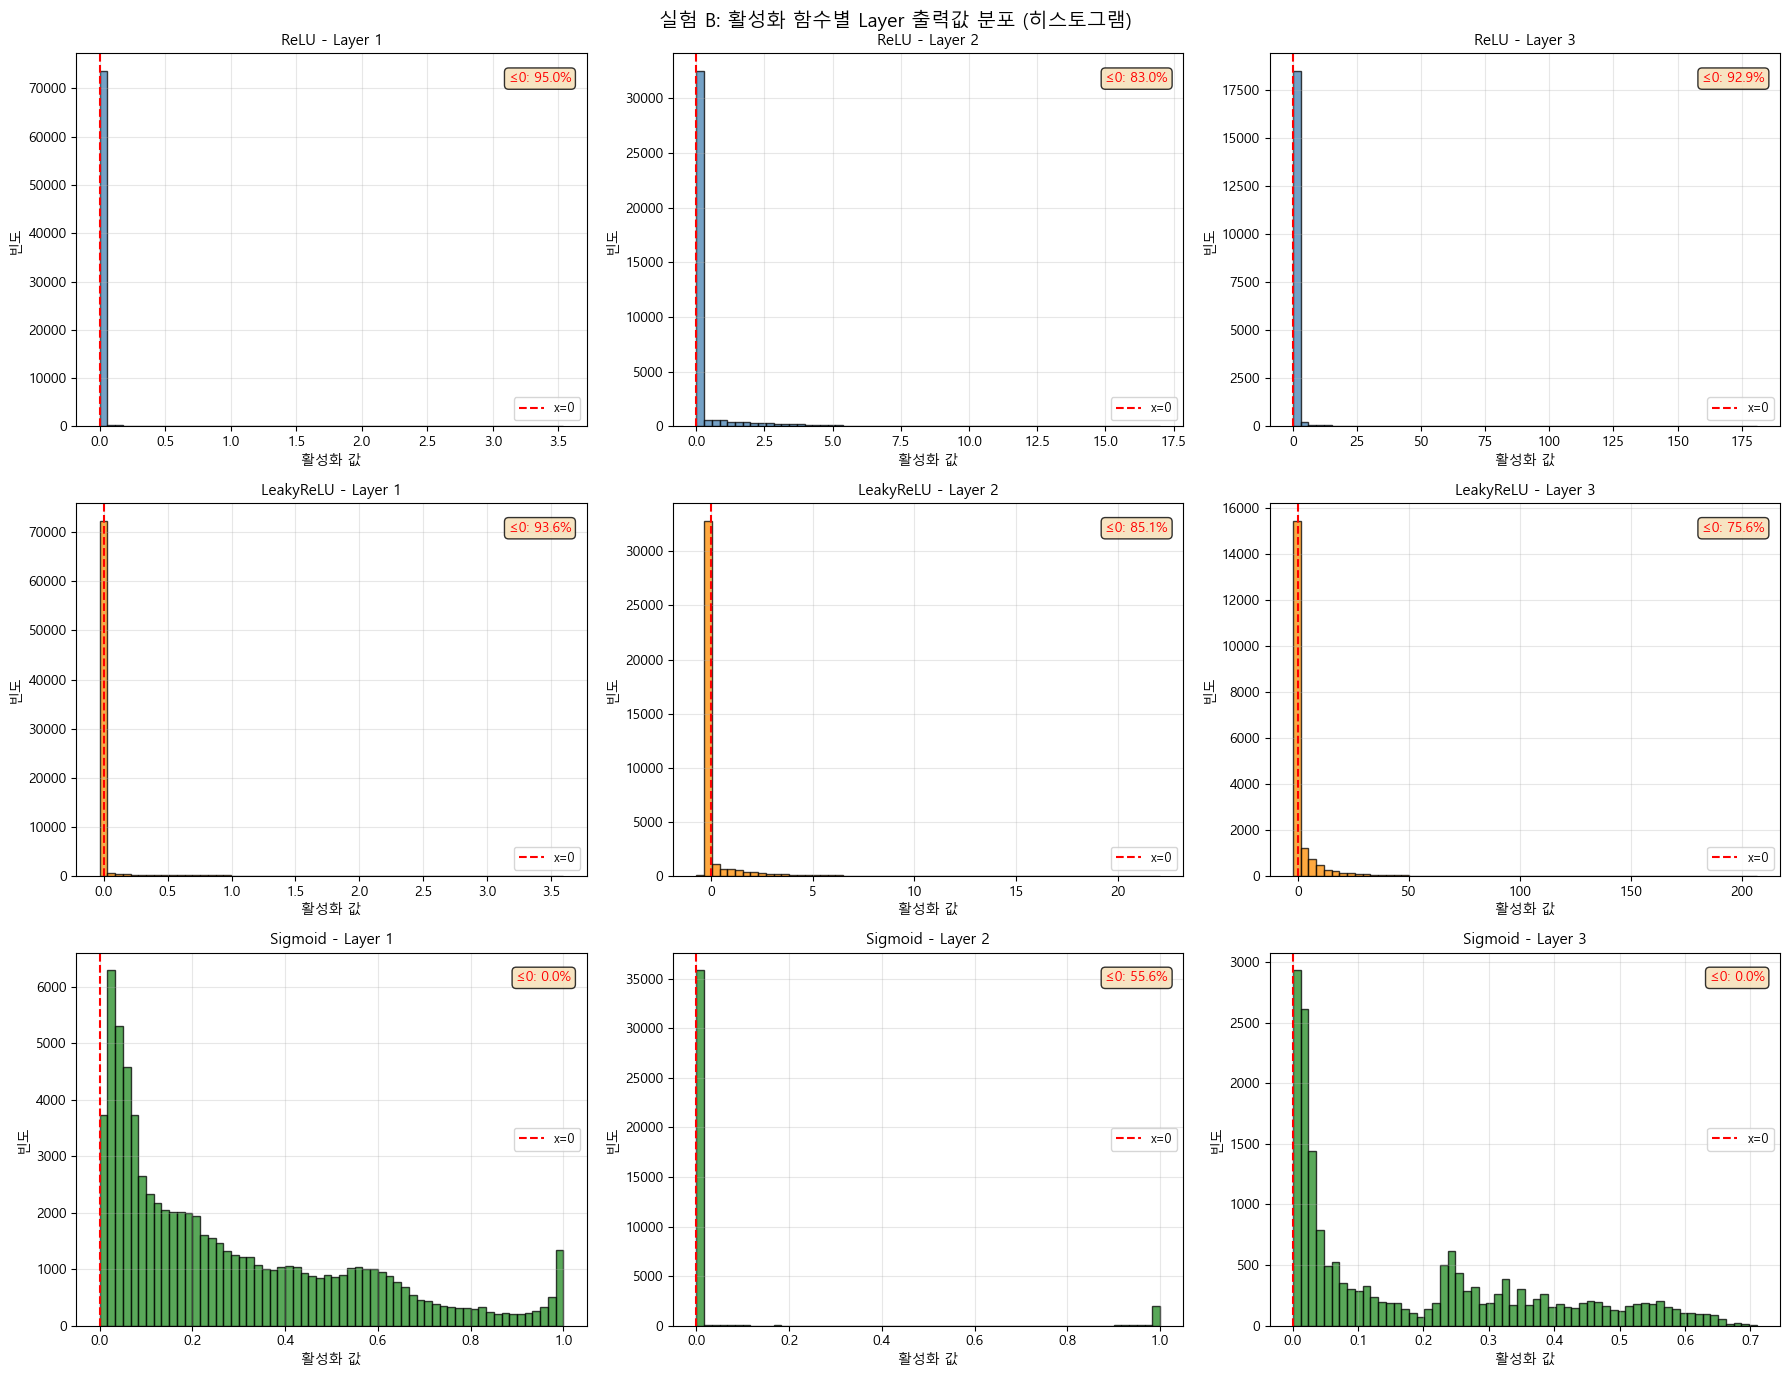

In [13]:
# ---
# 실험 B: Layer별 활성화 값 분포 히스토그램
# - 초반/중반/후반 학습 시점의 분포 변화를 에폭 기준 관찰
# ---

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, act in enumerate(ACT_LIST):
    hdata = collect_activations(models_B[act], test_loader_m, device, n_samples=300)
    for col, ldata in enumerate(hdata):
        ax = axes[row, col]
        flat = ldata.flatten()
        ax.hist(flat, bins=60, color=ACT_COLOR[act], alpha=0.75, edgecolor='k', lw=0.2)
        ax.axvline(x=0, color='red', ls='--', lw=1.5, label='x=0')
        dead_pct = (flat <= 1e-6).mean() * 100
        ax.set_title(f'{ACT_LABEL[act]} - Layer {col+1}', fontsize=11)
        ax.set_xlabel('활성화 값'); ax.set_ylabel('빈도')
        ax.text(0.97, 0.95, f'≤0: {dead_pct:.1f}%',
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                color='red', bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('실험 B: 활성화 함수별 Layer 출력값 분포 (히스토그램)', fontsize=14)
plt.tight_layout(); plt.show()


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


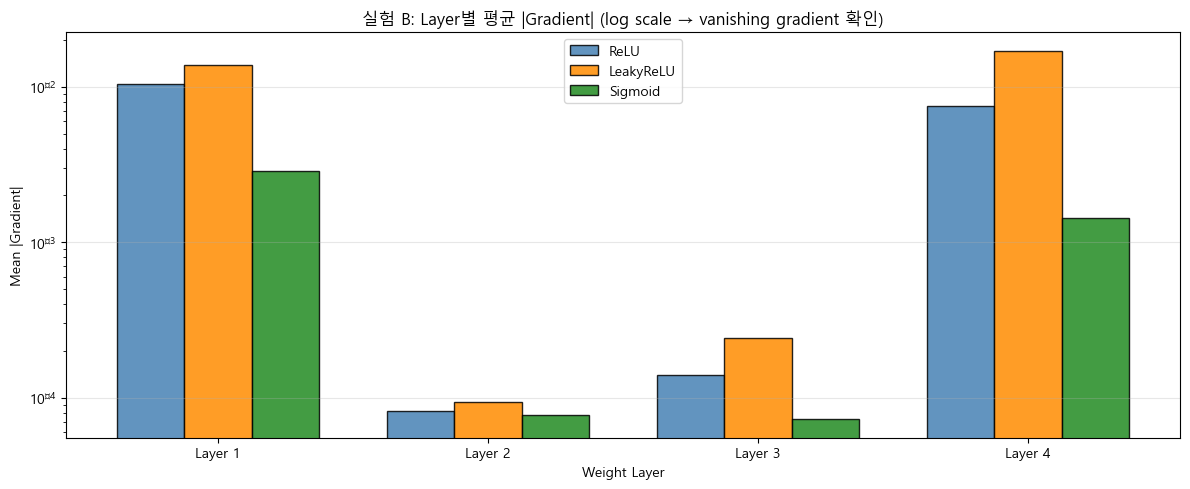

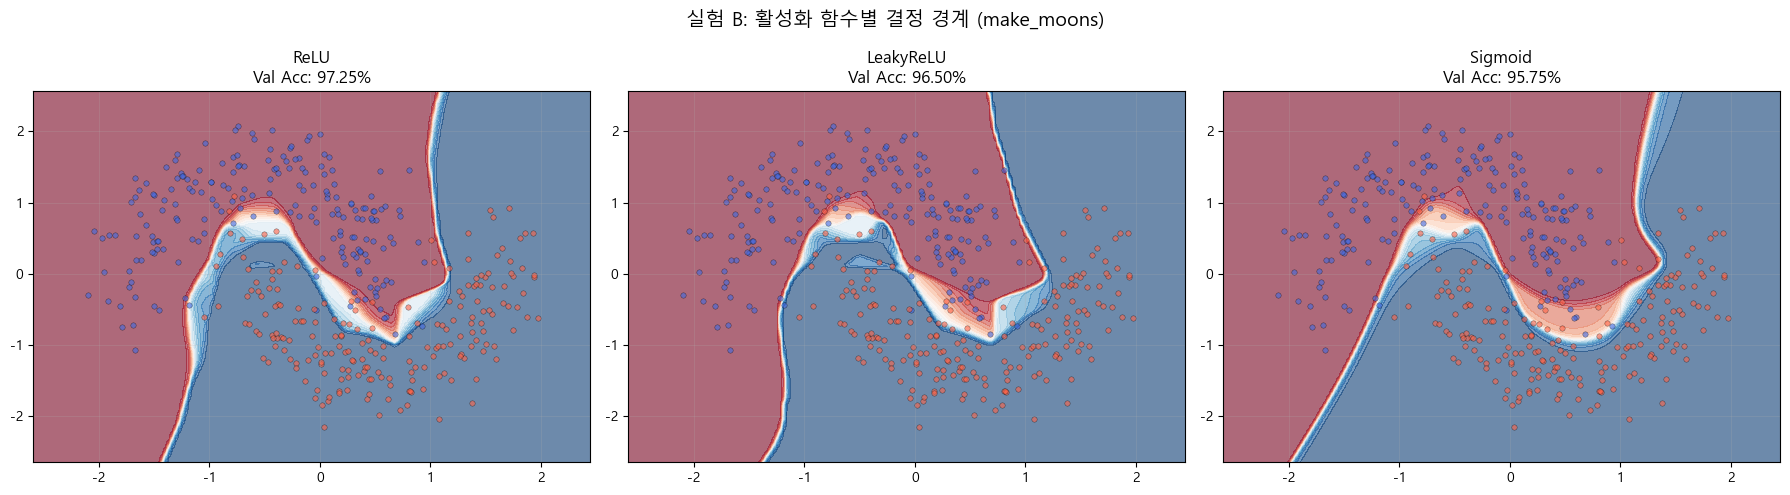

실험 B 정량 비교 표
활성화함수          L1 Dead%   L2 Dead%   L3 Dead%        최종 정확도%      수렴 속도
ReLU               60.9       46.1       62.5          97.25          1 epoch
LeakyReLU          55.1       14.1        4.7          96.50          1 epoch
Sigmoid             0.0        5.5        0.0          95.75          5 epoch


In [14]:
# ---
# 실험 B: Gradient Flow 분석 - Layer별 |gradient| 크기
# - log scale로 vanishing gradient 명확히 시각화
# ---

loss_fn_b = nn.CrossEntropyLoss()

def layer_grad_norms_2d(model, loader, loss_fn, device):
    model.train()
    inputs, labels = next(iter(loader))
    inputs, labels = inputs.to(device), labels.to(device)
    model.zero_grad()
    out  = model(inputs)
    loss = loss_fn(out, labels)
    loss.backward()
    return {name: p.grad.abs().mean().item()
            for name, p in model.named_parameters()
            if p.grad is not None and 'weight' in name}

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(HIDDEN_B) + 1)   # 4 weight layers
width = 0.25

for i, act in enumerate(ACT_LIST):
    grads = layer_grad_norms_2d(models_B[act], test_loader_m, loss_fn_b, device)
    vals  = list(grads.values())
    ax.bar(x_pos + i * width, vals, width,
           label=ACT_LABEL[act], color=ACT_COLOR[act], alpha=0.85, edgecolor='k')

ax.set_title('실험 B: Layer별 평균 |Gradient| (log scale → vanishing gradient 확인)', fontsize=12)
ax.set_xlabel('Weight Layer')
ax.set_ylabel('Mean |Gradient|')
ax.set_xticks(x_pos + width)
ax.set_xticklabels([f'Layer {i+1}' for i in range(len(x_pos))])
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# 결정 경계 시각화
def plot_boundary(model, X, y, ax, title):
    model.eval()
    h = 0.03
    x0, x1 = X[:,0].min()-0.5, X[:,0].max()+0.5
    y0, y1 = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    grid   = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.no_grad():
        Z = torch.softmax(model(grid), dim=1)[:,1].cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6, levels=20)
    ax.scatter(X[y==0,0], X[y==0,1], c='royalblue', s=15, alpha=0.6, edgecolors='k', lw=0.3)
    ax.scatter(X[y==1,0], X[y==1,1], c='tomato',    s=15, alpha=0.6, edgecolors='k', lw=0.3)
    ax.set_title(title, fontsize=12); ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, act in enumerate(ACT_LIST):
    acc = histories_B[act]['val_acc'][-1]
    plot_boundary(models_B[act], Xm_te, ym_te, axes[idx],
                  f'{ACT_LABEL[act]}\nVal Acc: {acc:.2f}%')
plt.suptitle('실험 B: 활성화 함수별 결정 경계 (make_moons)', fontsize=14)
plt.tight_layout(); plt.show()

# 정량 비교 표
print('실험 B 정량 비교 표')

print(f'{"활성화함수":<12} {"L1 Dead%":>10} {"L2 Dead%":>10} {"L3 Dead%":>10} {"최종 정확도%":>14} {"수렴 속도":>10}')
for act in ACT_LIST:
    r   = dead_ratios_B[act]
    acc = histories_B[act]['val_acc'][-1]
    conv = next((i+1 for i, a in enumerate(histories_B[act]['val_acc']) if a > 85), EPOCHS_B)
    print(f'{ACT_LABEL[act]:<12} {r[0]:>10.1f} {r[1]:>10.1f} {r[2]:>10.1f} {acc:>14.2f} {conv:>10d} epoch')


### 실험 B 해설 및 분석

#### 1. Dead ReLU 발생이 학습에 미치는 영향
ReLU는 입력이 음수이면 출력 0, gradient도 0이다. `small_init=True`로 초기화한 경우,  
많은 뉴런이 처음부터 음수 값을 받아 **영구적으로 0**을 출력하게 된다(Dead ReLU).  
Dead 비율이 높은 레이어는 **역전파 신호가 차단**되어 이전 레이어로 gradient가 전달되지 않는다.  
결과: 해당 레이어 이하의 가중치는 업데이트가 멈추고 학습이 정체된다.

#### 2. LeakyReLU의 Dead ReLU 완화 효과
LeakyReLU는 음수 입력에서도 `slope = 0.01`의 작은 기울기를 유지하기 때문에 gradient가 완전히 0이 되지 않는다.  
따라서 음수 입력에서도 gradient가 0이 되지 않아 Dead Neuron 비율이 ReLU 대비 현저히 낮다.  
히트맵에서 LeakyReLU는 모든 레이어에서 활성화 패턴이 다양하게 유지됨을 확인할 수 있다.

#### 3. Sigmoid Vanishing Gradient
Sigmoid의 출력은 항상 (0, 1) 사이이며, gradient는 sigma(x)(1-sigma(x)) 형태다.  
입력의 절댓값이 4를 넘으면 gradient가 0.01 이하로 떨어져 학습이 거의 멈춘다.
다층 구조에서 이 값이 곱해지면 앞 레이어의 gradient는 **지수적으로 감소**하여 학습이 정체된다.  
Gradient 막대 그래프에서 Sigmoid의 앞 레이어 gradient가 다른 함수 대비 매우 작음을 확인할 수 있다.

#### 4. 각 Layer의 학습 기여도
- **ReLU**: 후반 레이어는 활성화되지만 초반 레이어는 Dead Neuron으로 기여 없음
- **LeakyReLU**: 모든 레이어가 고르게 학습에 기여 → 가장 빠른 수렴
- **Sigmoid**: 모든 레이어에서 gradient 크기가 작아 기여도 균일하게 낮음

---
## 실험 C: 최적화 알고리즘 비교 — SGD / SGD+Momentum / Adam

**실험 목표**: 세 Optimizer의 수렴 속도·안정성·최종 성능 비교 + 학습률 영향 분석  
**데이터셋**: Digits Dataset (scikit-learn, 8×8 이미지, 10 클래스)  
**조건**: 동일 네트워크(256→128→10) + CrossEntropy  
- 학습률: SGD(0.1/0.01/0.001), SGD+Mom(0.01/0.005/0.001), Adam(0.01/0.001/0.0001)
- ExponentialLR(gamma=0.9) 스케줄러 추가 실험

Digits 데이터: 입력=64차원  클래스=10
훈련: 1437  테스트: 360


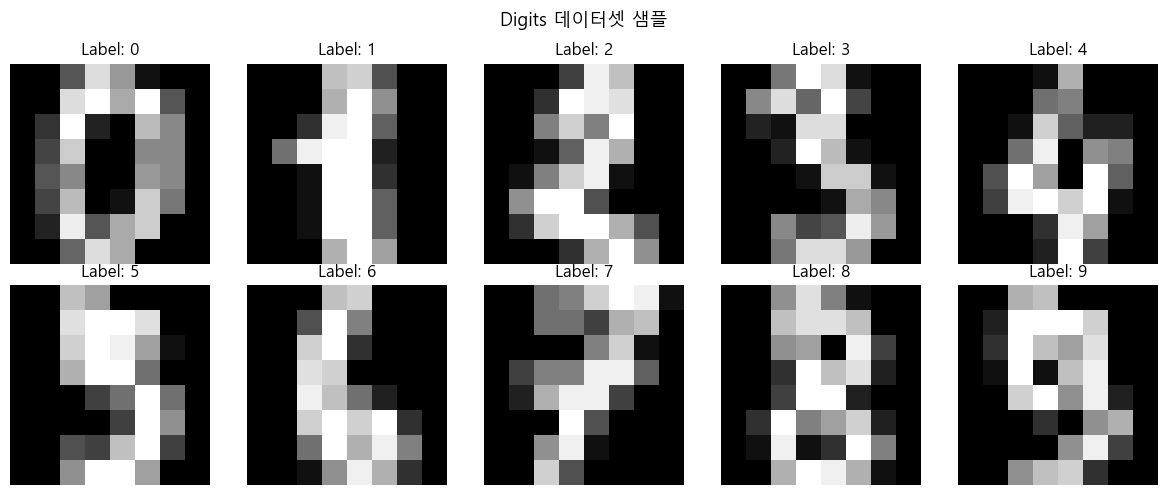

In [15]:
# ---
# 실험 C: Digits Dataset 로드
# ---

digits  = load_digits()
X_dig   = digits.data.astype(np.float32) / 16.0   # [0, 1] 정규화
y_dig   = digits.target.astype(np.int64)

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=SEED)

train_loader_d, test_loader_d = make_loader(Xd_tr, yd_tr, Xd_te, yd_te, batch=32)

print(f'Digits 데이터: 입력={X_dig.shape[1]}차원  클래스={len(np.unique(y_dig))}')
print(f'훈련: {len(Xd_tr)}  테스트: {len(Xd_te)}')

# 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Digits 데이터셋 샘플', fontsize=13)
plt.tight_layout(); plt.show()

In [16]:
# ---
# 실험 C: SGD / SGD+Momentum / Adam 학습률별 비교
# ---

EPOCHS_C = 50
INPUT_C  = 64     # 8×8
HIDDEN_C = [256, 128]
N_CLS_C  = 10

# 각 optimizer별 테스트 학습률 목록
OPT_LR_GRID = {
    'SGD':          [0.1,  0.01, 0.001],
    'SGD+Momentum': [0.01, 0.005, 0.001],
    'Adam':         [0.01, 0.001, 0.0001]
}

all_results_C = {}   # all_results_C[opt_name][lr] = history

for opt_name, lr_list in OPT_LR_GRID.items():
    all_results_C[opt_name] = {}
    for lr in lr_list:
        print(f'  {opt_name}  LR={lr}')
        torch.manual_seed(SEED)
        model   = MLP(INPUT_C, HIDDEN_C, N_CLS_C, activation='relu').to(device)
        loss_fn = nn.CrossEntropyLoss()

        if opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr)
        elif opt_name == 'SGD+Momentum':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        else:   # Adam
            optimizer = optim.Adam(model.parameters(), lr=lr)

        history = run_training(
            model, train_loader_d, test_loader_d,
            loss_fn, optimizer, EPOCHS_C, device, verbose=False)

        all_results_C[opt_name][lr] = {'history': history, 'model': model}
        print(f'    → 최종 Val Acc: {history["val_acc"][-1]:.2f}%')

print('\n실험 C 학습 완료!')

  SGD  LR=0.1


    → 최종 Val Acc: 96.67%
  SGD  LR=0.01


    → 최종 Val Acc: 93.06%
  SGD  LR=0.001


    → 최종 Val Acc: 47.22%
  SGD+Momentum  LR=0.01


    → 최종 Val Acc: 96.94%
  SGD+Momentum  LR=0.005


    → 최종 Val Acc: 96.67%
  SGD+Momentum  LR=0.001


    → 최종 Val Acc: 93.06%
  Adam  LR=0.01


    → 최종 Val Acc: 98.33%
  Adam  LR=0.001


    → 최종 Val Acc: 97.78%
  Adam  LR=0.0001


    → 최종 Val Acc: 96.39%

실험 C 학습 완료!


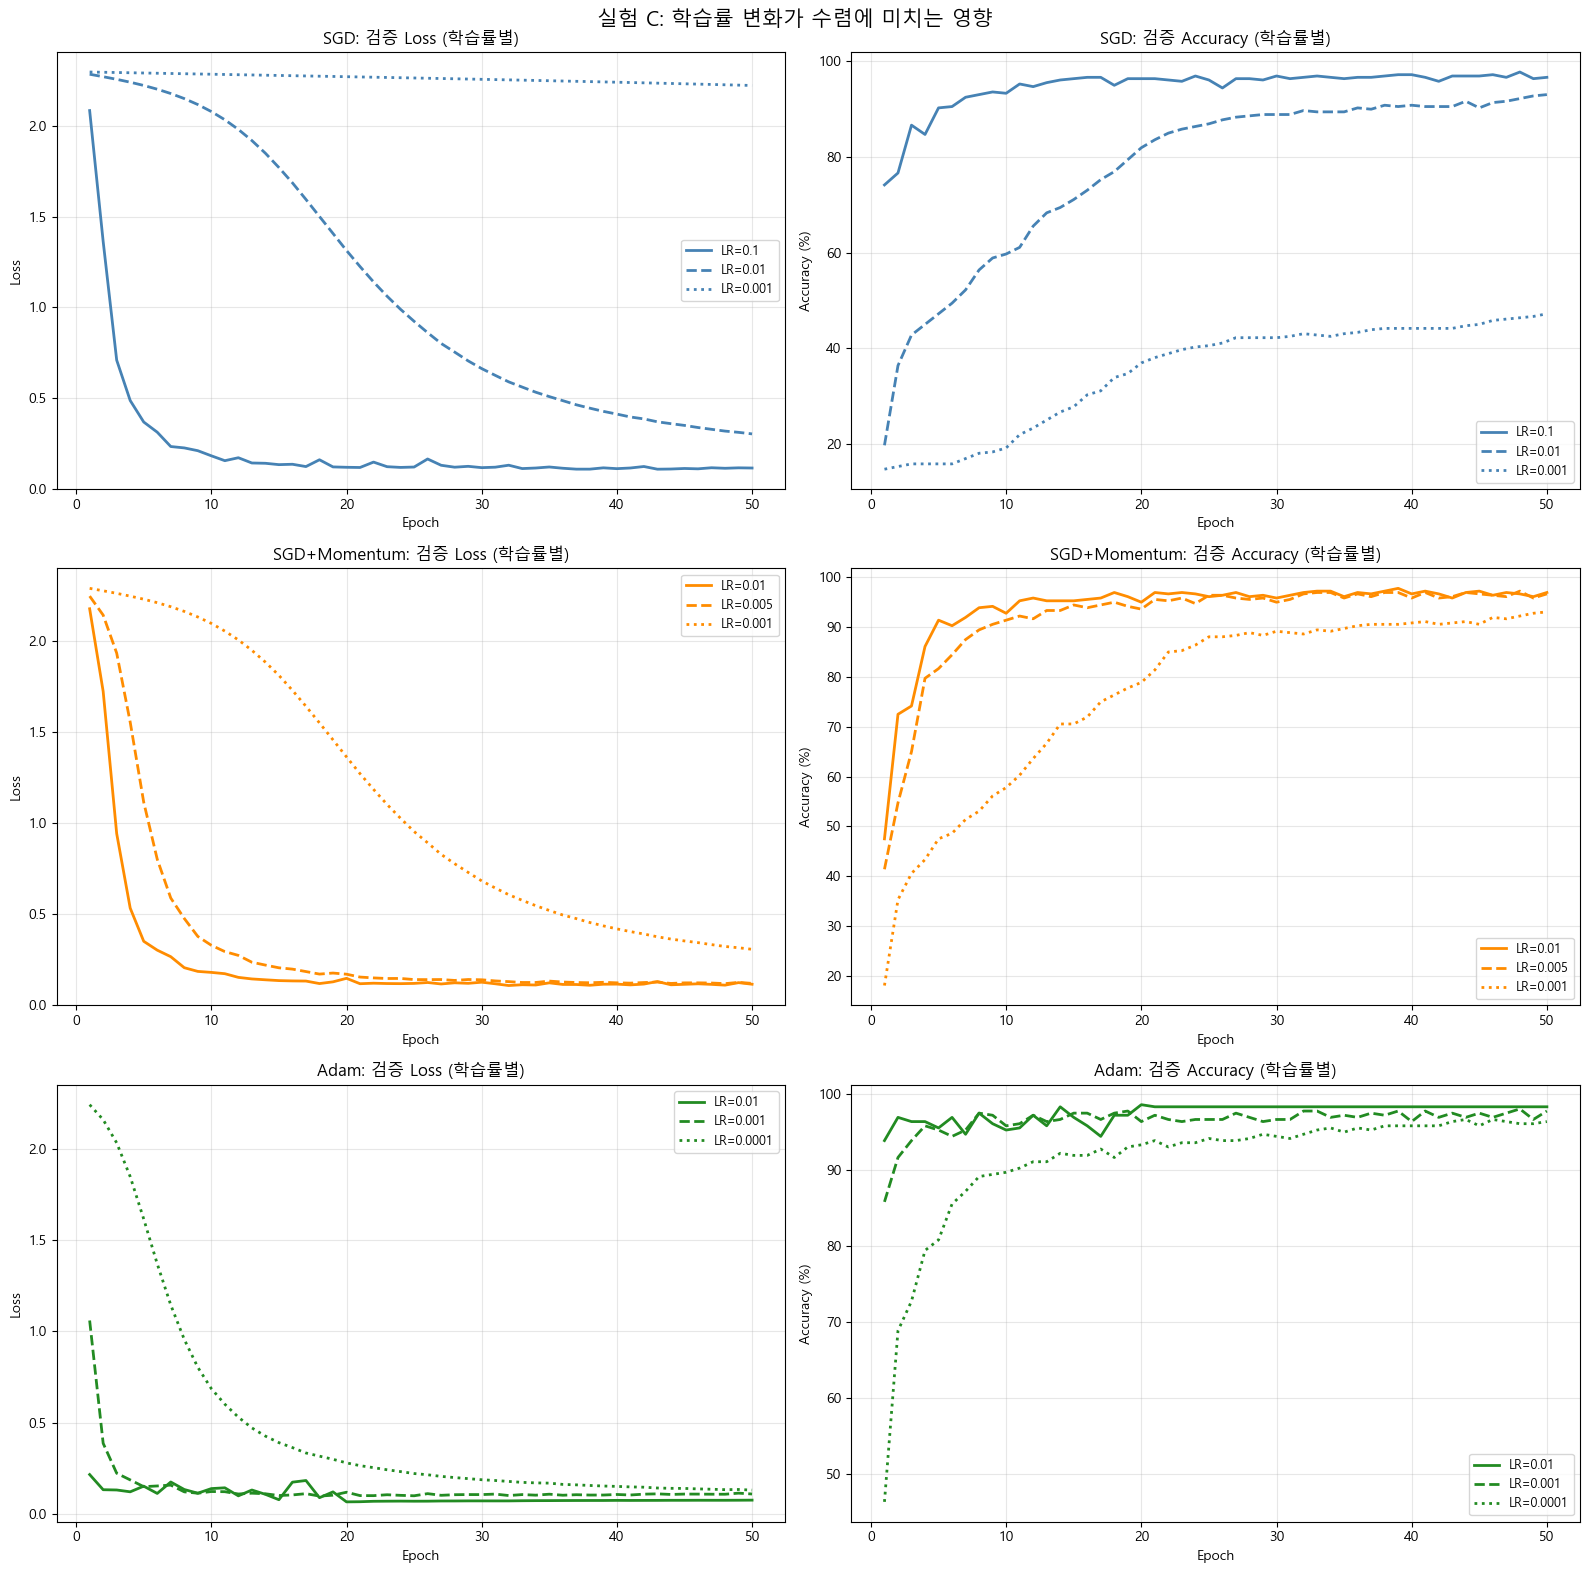

In [17]:
# ---
# 실험 C: 학습률별 Val Loss / Accuracy 곡선
# ---

OPT_COLOR = {'SGD': 'steelblue', 'SGD+Momentum': 'darkorange', 'Adam': 'forestgreen'}
LINE_STYLE = {0: '-', 1: '--', 2: ':'}

ep_c = range(1, EPOCHS_C + 1)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

for row, (opt_name, lr_list) in enumerate(OPT_LR_GRID.items()):
    for j, lr in enumerate(lr_list):
        h = all_results_C[opt_name][lr]['history']
        c = OPT_COLOR[opt_name]
        axes[row, 0].plot(ep_c, h['val_loss'], color=c, ls=LINE_STYLE[j],
                          label=f'LR={lr}', lw=2)
        axes[row, 1].plot(ep_c, h['val_acc'],  color=c, ls=LINE_STYLE[j],
                          label=f'LR={lr}', lw=2)
    for col in range(2):
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].legend(fontsize=9); axes[row, col].grid(alpha=0.3)
    axes[row, 0].set_title(f'{opt_name}: 검증 Loss (학습률별)')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 1].set_title(f'{opt_name}: 검증 Accuracy (학습률별)')
    axes[row, 1].set_ylabel('Accuracy (%)')

plt.suptitle('실험 C: 학습률 변화가 수렴에 미치는 영향', fontsize=15)
plt.tight_layout(); plt.show()

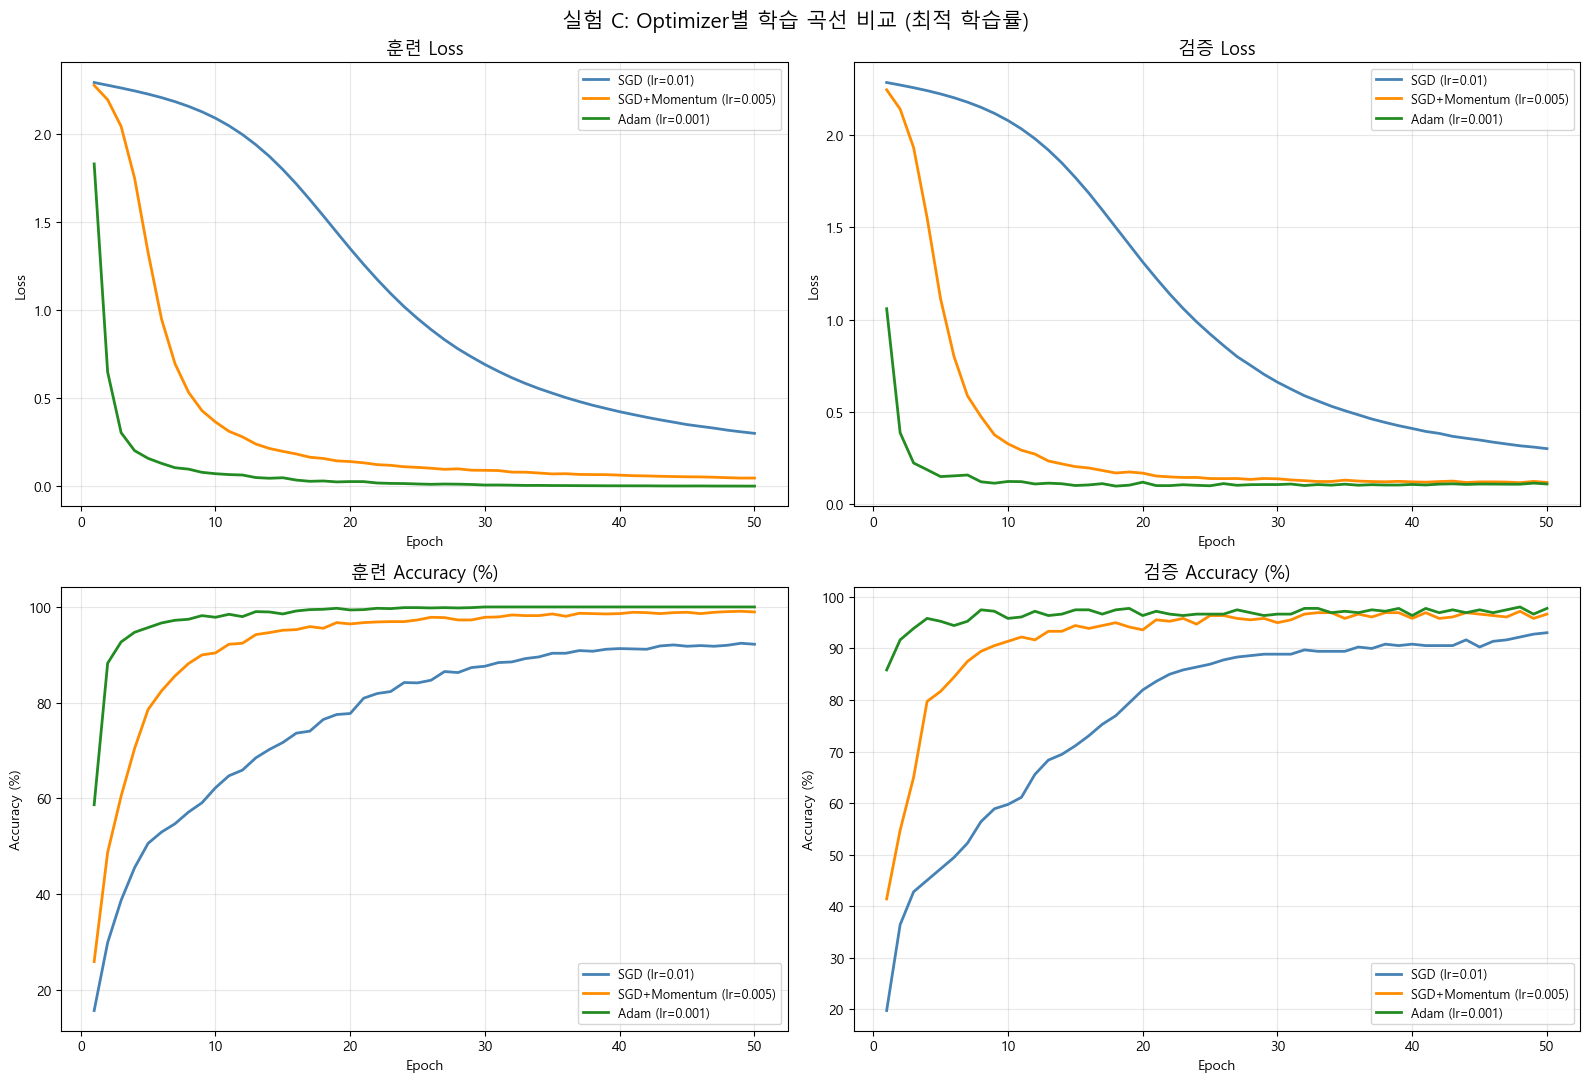

In [18]:
# ---
# 실험 C: 최적 학습률 선택 후 세 Optimizer 직접 비교
# ---

BEST_LR = {'SGD': 0.01, 'SGD+Momentum': 0.005, 'Adam': 0.001}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for opt_name, lr in BEST_LR.items():
    h = all_results_C[opt_name][lr]['history']
    c = OPT_COLOR[opt_name]
    lb = f'{opt_name} (lr={lr})'
    axes[0,0].plot(ep_c, h['train_loss'], color=c, label=lb, lw=2)
    axes[0,1].plot(ep_c, h['val_loss'],   color=c, label=lb, lw=2)
    axes[1,0].plot(ep_c, h['train_acc'],  color=c, label=lb, lw=2)
    axes[1,1].plot(ep_c, h['val_acc'],    color=c, label=lb, lw=2)

titles = ['훈련 Loss', '검증 Loss', '훈련 Accuracy (%)', '검증 Accuracy (%)']
ylabels = ['Loss', 'Loss', 'Accuracy (%)', 'Accuracy (%)']
for ax, t, yl in zip(axes.flatten(), titles, ylabels):
    ax.set_title(t, fontsize=13); ax.set_xlabel('Epoch')
    ax.set_ylabel(yl); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('실험 C: Optimizer별 학습 곡선 비교 (최적 학습률)', fontsize=15)
plt.tight_layout(); plt.show()

ExponentialLR(gamma=0.9) 적용 실험


  SGD: 최종 Val Acc = 59.17%


  SGD+Momentum: 최종 Val Acc = 92.50%


  Adam: 최종 Val Acc = 97.22%


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


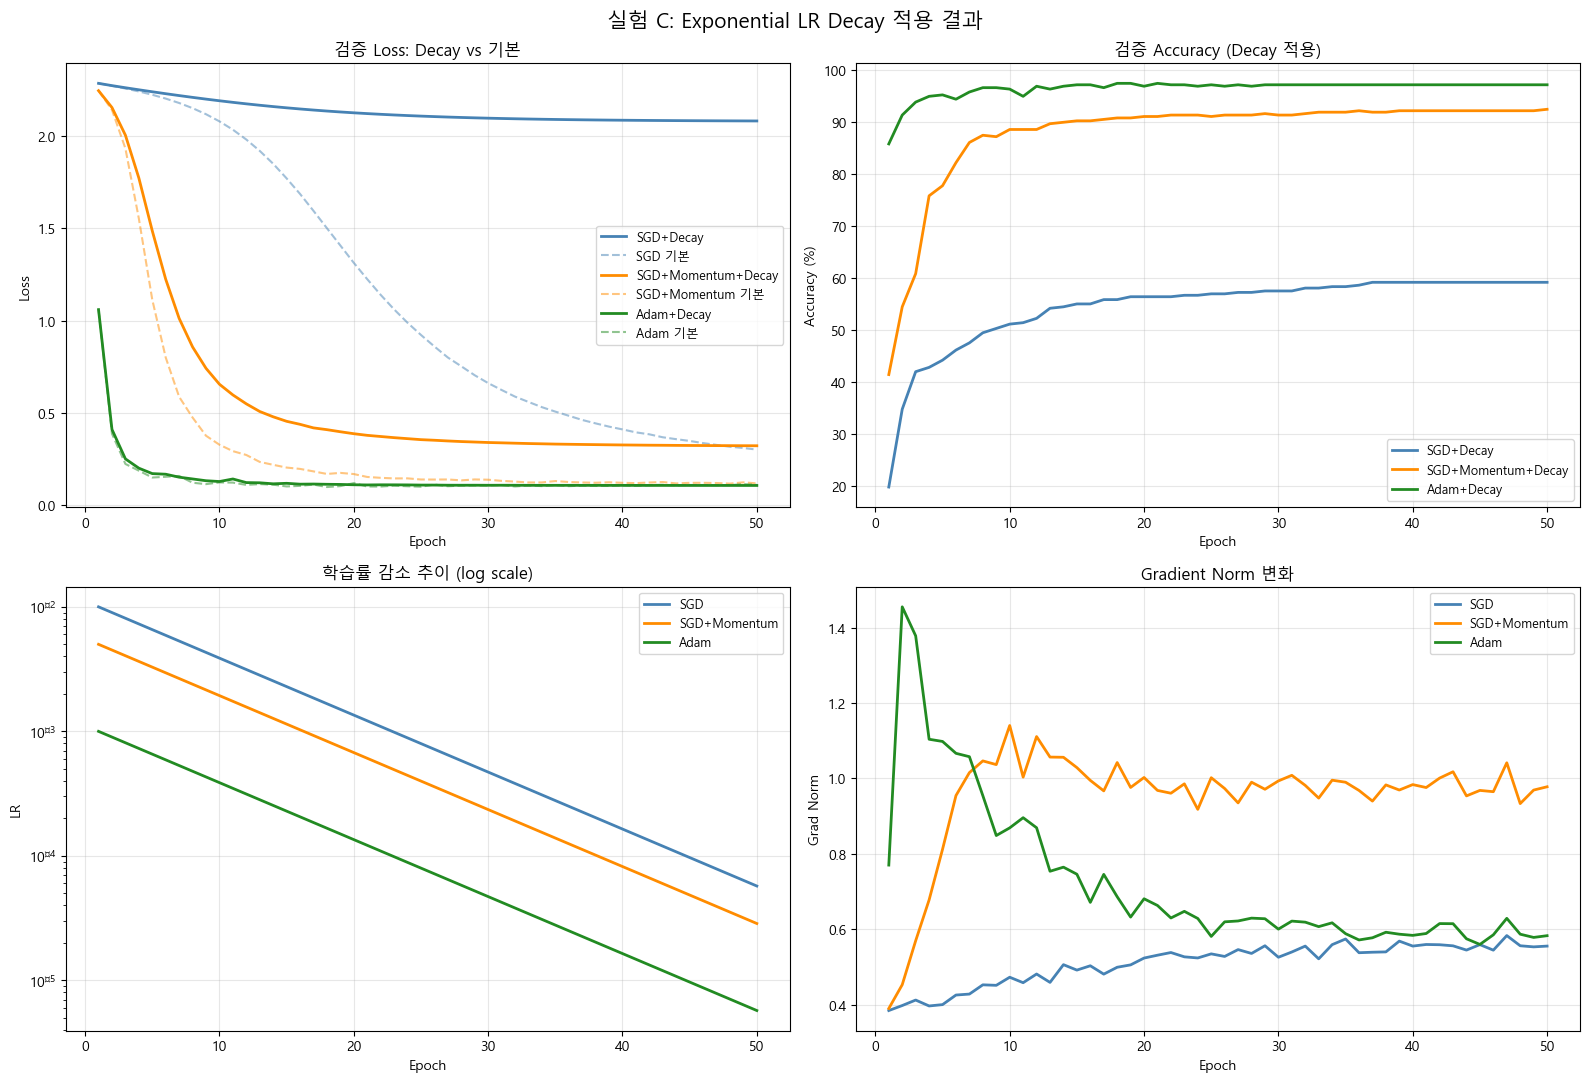

In [19]:
# ---
# 실험 C: Exponential LR Decay 적용 실험
# scheduler = ExponentialLR(gamma=0.9) → 매 에폭 lr *= 0.9
# ---

DECAY_CFG = {
    'SGD':          (optim.SGD,  {'lr': 0.01}),
    'SGD+Momentum': (optim.SGD,  {'lr': 0.005, 'momentum': 0.9}),
    'Adam':         (optim.Adam, {'lr': 0.001})
}

histories_decay = {}
print('ExponentialLR(gamma=0.9) 적용 실험')

for opt_name, (OptCls, kwargs) in DECAY_CFG.items():
    torch.manual_seed(SEED)
    model     = MLP(INPUT_C, HIDDEN_C, N_CLS_C, activation='relu').to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = OptCls(model.parameters(), **kwargs)
    # 지수 감소 스케줄러 - 매 에폭 lr = lr * gamma
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    history = run_training(
        model, train_loader_d, test_loader_d,
        loss_fn, optimizer, EPOCHS_C, device,
        scheduler=scheduler, verbose=False)
    histories_decay[opt_name] = history
    print(f'  {opt_name}: 최종 Val Acc = {history["val_acc"][-1]:.2f}%')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for opt_name in DECAY_CFG:
    h_dec  = histories_decay[opt_name]
    lr_key = DECAY_CFG[opt_name][1]['lr']
    h_base = all_results_C[opt_name][lr_key]['history']
    c = OPT_COLOR[opt_name]

    axes[0,0].plot(ep_c, h_dec['val_loss'],   color=c, ls='-',  label=f'{opt_name}+Decay', lw=2)
    axes[0,0].plot(ep_c, h_base['val_loss'],  color=c, ls='--', label=f'{opt_name} 기본',  lw=1.5, alpha=0.5)
    axes[0,1].plot(ep_c, h_dec['val_acc'],    color=c, ls='-',  label=f'{opt_name}+Decay', lw=2)
    axes[1,0].plot(ep_c, h_dec['lr'],         color=c, ls='-',  label=opt_name,            lw=2)
    axes[1,1].plot(ep_c, h_dec['grad_norms'], color=c, ls='-',  label=opt_name,            lw=2)

axes[0,0].set_title('검증 Loss: Decay vs 기본');       axes[0,0].set_ylabel('Loss')
axes[0,1].set_title('검증 Accuracy (Decay 적용)');    axes[0,1].set_ylabel('Accuracy (%)')
axes[1,0].set_title('학습률 감소 추이 (log scale)');  axes[1,0].set_ylabel('LR'); axes[1,0].set_yscale('log')
axes[1,1].set_title('Gradient Norm 변화');            axes[1,1].set_ylabel('Grad Norm')

for ax in axes.flatten():
    ax.set_xlabel('Epoch'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('실험 C: Exponential LR Decay 적용 결과', fontsize=15)
plt.tight_layout(); plt.show()

In [20]:
# ---
# 실험 C: 정량 비교 표
# ---

print('\n' + '='*90)
print('실험 C 정량 비교 표 1 - Optimizer × 학습률 (최종 검증 정확도 %)')
print(f'{"Optimizer":<16} {"LR":>8} {"Val Acc%":>10} {"Val Loss":>10} {"수렴Epoch":>10} {"Stability":>12}')
for opt_name, lr_list in OPT_LR_GRID.items():
    for lr in lr_list:
        h    = all_results_C[opt_name][lr]['history']
        acc  = h['val_acc'][-1]
        loss = min(h['val_loss'])
        conv = next((i+1 for i, a in enumerate(h['val_acc']) if a > 90), EPOCHS_C)
        std  = np.std(h['val_acc'][-10:])
        stab = 'High' if std < 0.5 else ('Med' if std < 2.0 else 'Low')
        print(f'{opt_name:<16} {lr:>8.4f} {acc:>10.2f} {loss:>10.4f} {conv:>10} {stab:>12}')
    print()

print('실험 C 정량 비교 표 2 - Exponential Decay 적용 결과')
print(f'{"Optimizer":<16} {"Val Acc%":>10} {"Val Loss":>10} {"최종 LR":>10} {"Stability":>12}')
for opt_name in DECAY_CFG:
    h    = histories_decay[opt_name]
    acc  = h['val_acc'][-1]
    loss = min(h['val_loss'])
    lr_f = h['lr'][-1]
    std  = np.std(h['val_acc'][-10:])
    stab = 'High' if std < 0.5 else ('Med' if std < 2.0 else 'Low')
    print(f'{opt_name:<16} {acc:>10.2f} {loss:>10.4f} {lr_f:>10.6f} {stab:>12}')



실험 C 정량 비교 표 1 - Optimizer × 학습률 (최종 검증 정확도 %)
Optimizer              LR   Val Acc%   Val Loss    수렴Epoch    Stability
SGD                0.1000      96.67     0.1071          5         High
SGD                0.0100      93.06     0.3017         36          Med
SGD                0.0010      47.22     2.2225         50          Med

SGD+Momentum       0.0100      96.94     0.1070          5         High
SGD+Momentum       0.0050      96.67     0.1175          9         High
SGD+Momentum       0.0010      93.06     0.3059         36          Med

Adam               0.0100      98.33     0.0674          1         High
Adam               0.0010      97.78     0.0989          2         High
Adam               0.0001      96.39     0.1317         11         High

실험 C 정량 비교 표 2 - Exponential Decay 적용 결과
Optimizer          Val Acc%   Val Loss      최종 LR    Stability
SGD                   59.17     2.0809   0.000057         High
SGD+Momentum          92.50     0.3224   0.000029         High

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


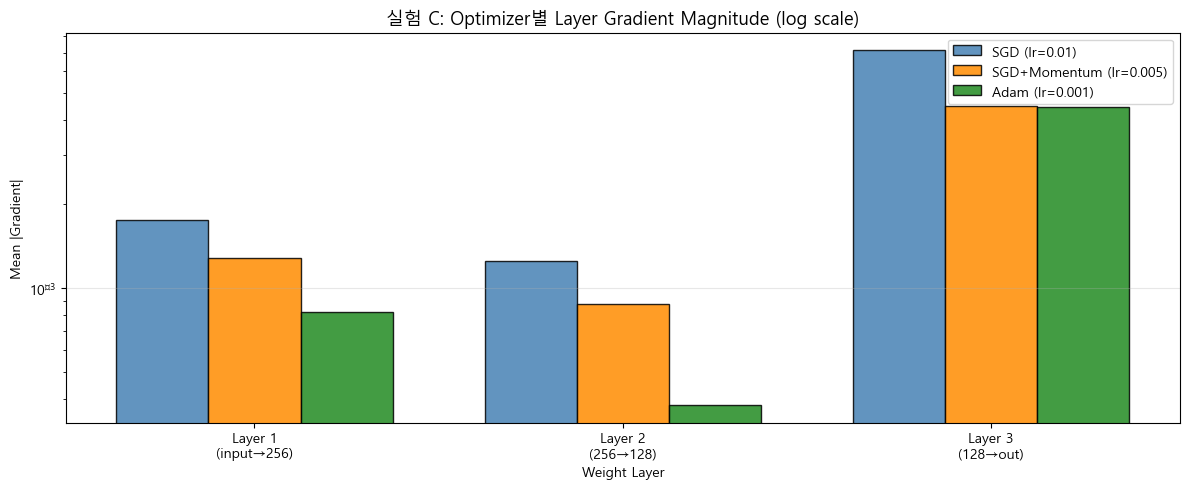

In [21]:
# ---
# 실험 C: Optimizer별 Gradient Flow 분석
# - 동일 네트워크에서 Optimizer에 따라 gradient 크기가 어떻게 다른지 확인
# ---

loss_fn_c = nn.CrossEntropyLoss()

def get_layer_grads_1d(model, loader, loss_fn, device):
    model.train()
    inputs, labels = next(iter(loader))
    inputs, labels = inputs.to(device), labels.to(device)
    model.zero_grad()
    out  = model(inputs)
    loss = loss_fn(out, labels)
    loss.backward()
    return {name: p.grad.abs().mean().item()
            for name, p in model.named_parameters()
            if p.grad is not None and 'weight' in name}


fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(3)   # 3 weight layers
w     = 0.25

for i, (opt_name, lr) in enumerate(BEST_LR.items()):
    model = all_results_C[opt_name][lr]['model']
    grads = get_layer_grads_1d(model, test_loader_d, loss_fn_c, device)
    ax.bar(x_pos + i * w, list(grads.values()), w,
           label=f'{opt_name} (lr={lr})', color=OPT_COLOR[opt_name], alpha=0.85, edgecolor='k')

ax.set_title('실험 C: Optimizer별 Layer Gradient Magnitude (log scale)', fontsize=13)
ax.set_xlabel('Weight Layer')
ax.set_ylabel('Mean |Gradient|')
ax.set_xticks(x_pos + w)
ax.set_xticklabels(['Layer 1\n(input→256)', 'Layer 2\n(256→128)', 'Layer 3\n(128→out)'])
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 실험 C 해설 및 분석

#### 1. SGD / SGD+Momentum / Adam 수렴 곡선 차이

| Optimizer | 업데이트 수식 | 특징 |
|-----------|--------------|------|
| SGD | 고정 LR로 매 배치마다 gradient 방향으로 업데이트 | 방향 진동, 느린 수렴 |
| SGD+Momentum | 이전 velocity를 누적해 관성을 추가 | 진동 감쇠, 빠른 수렴 |
| Adam | 1차/2차 모멘트로 파라미터별 적응 학습률 자동 조정 | 가장 빠른 초기 수렴, 안정적 |

#### 2. 학습률 변화가 안정성에 미치는 영향
- **너무 큰 LR**: Overshooting → Loss가 진동하거나 발산
- **너무 작은 LR**: 수렴이 매우 느려 지정 에폭 내 최적점 미달
- SGD는 학습률에 민감, Adam은 적응 학습률 덕분에 넓은 범위에서 안정적

#### 3. Adam이 초기 수렴에 빠른 이유
Adam의 편향 보정(bias correction): 초기에 moment 추정값이 0에 치우쳐져 있기 때문에 이를 보정해 초기부터 적절한 스텝 크기를 유지한다.

#### 4. Exponential Decay 효과
- 학습 초반: 큰 LR → 빠른 수렴
- 학습 후반: LR이 기하급수적으로 감소 → 최적점 근방에서 fine-tuning 효과
- Gradient Norm 그래프에서 후반부 gradient 크기가 감소하며 수렴 안정성이 증가함을 확인
- 과적합 방지 효과: 후반 학습률 감소로 너무 날카로운 최솟값(sharp minima)에 빠지는 것을 방지

#### 5. Gradient Vanishing/Exploding 분석
- SGD에서 큰 LR(0.1)을 사용할 경우 gradient exploding 위험 → Loss 발산
- Adam은 2차 모멘트 스케일링으로 gradient가 클 때 자동으로 스텝 크기를 줄여 exploding을 방지
- SGD+Momentum은 관성 항이 너무 크면 overshooting 발생 (lr × momentum 조합 중요)

#### 6. 동일 네트워크에서 서로 다른 학습 패턴의 수식적 근거
- SGD: 고정 learning rate로 모든 파라미터를 동일하게 업데이트 → 평탄한 방향과 가파른 방향 모두 같은 스텝 → 진동
- SGD+Momentum: velocity 누적으로 일관된 방향에서 가속, 진동 방향에서 상쇄 → 수렴 가속
- Adam: 각 파라미터마다 독립적인 학습률 → gradient가 큰 파라미터는 작은 스텝, 작은 파라미터는 큰 스텝 → 고른 업데이트

---
## 종합 결론

### 공통 질문 답변

#### Q1. 손실 함수·활성화 함수·최적화 알고리즘이 학습 곡선에 미치는 영향
| 요소 | 수렴 속도 | 진동 | 학습 정체 |
|------|-----------|------|----------|
| CrossEntropy | 빠름 | 낮음 | 없음 |
| MSE | 느림 | 중간 | gradient 소멸 시 정체 |
| LeakyReLU | 빠름 | 낮음 | 없음 |
| ReLU | 중간 | 낮음 | Dead neuron 구간에서 정체 |
| Sigmoid | 느림 | 낮음 | vanishing gradient로 정체 |
| Adam | 가장 빠름 | 가장 낮음 | 없음 |
| SGD+Momentum | 빠름 | 낮음 | 없음 |
| SGD | 느림 | 높음 | 큰 LR 시 발산 |

#### Q2. Loss 감소와 Accuracy 불균형 원인
MSE Loss에서 관찰된다. MSE는 각 출력값의 수치적 오차를 최소화하는 방향이므로,  
Loss가 감소해도 **분류 경계를 학습하는 것과 직접적인 연관이 없어** Accuracy가 정체될 수 있다.  
**해결책**: CrossEntropy 사용 또는 Label Smoothing 추가.

#### Q3. Layer별 Activation 분포 변화
- ReLU: 학습 초반 small_init으로 Dead neuron 다수 → 후반에도 일부 지속
- Sigmoid: 초반부터 [0.4~0.6] 범위에 집중(포화 이전) → 학습 진행 시 포화 구간 증가
- LeakyReLU: 전 레이어에서 다양한 활성화 분포 유지

#### Q4. Gradient 소멸/폭발의 영향
- **소멸(Vanishing)**: 앞 레이어 가중치 업데이트 불가 → 얕은 표현만 학습
- **폭발(Exploding)**: 가중치 NaN 또는 Loss 발산
- **해결책**: BatchNorm, Gradient Clipping, Xavier/He 초기화, Residual Connection

### 실험별 최적 설정 추천
| 기준 | 추천 설정 |
|------|----------|
| 분류 문제 손실 함수 | CrossEntropyLoss |
| 활성화 함수 | LeakyReLU (ReLU 대비 안정적) |
| Optimizer | Adam (lr=0.001) + ExponentialLR(gamma=0.95) |
| 가중치 초기화 | He initialization (ReLU 계열) |